<a href="https://colab.research.google.com/github/edmilsondejesus/scrapy_extract/blob/main/Word2Vec_Stil_2024_extractor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STIL 2024 — Extração e Análise de Corpus

## 1. Setup

In [ ]:
!pip install -q requests beautifulsoup4 spacy langdetect deep-translator PyMuPDF tqdm nltk wordcloud
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 84.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 106.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import json, os, re, unicodedata, textwrap
import requests
import fitz
import spacy
from bs4 import BeautifulSoup
from langdetect import detect
from deep_translator import GoogleTranslator

nlp = spacy.load("pt_core_news_sm")
nlp.max_length = 3_000_000
os.makedirs("files", exist_ok=True)

## 2. Input — Cole o JSON do DBLP aqui

In [ ]:
input_data =[
  {
          "@score": "1",
          "@id": "1122900",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1226",
                  "text": "Giovana Y. Nakashima"
                },
                {
                  "@pid": "419/1309",
                  "text": "Higor D. C. Santos"
                },
                {
                  "@pid": "419/1286",
                  "text": "Jone W. M. Soares"
                },
                {
                  "@pid": "226/3895",
                  "text": "Mário Uliani Neto"
                },
                {
                  "@pid": "333/8745",
                  "text": "Fernando O. Runstein"
                },
                {
                  "@pid": "44/8336",
                  "text": "Ricardo P. V. Violato"
                },
                {
                  "@pid": "419/1145",
                  "text": "Marcus Lima"
                }
              ]
            },
            "title": "Avaliação de modelos para detecção de ataques de replay usando diferentes bases de dados.",
            "venue": "STIL",
            "pages": "6-11",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/NakashimaSSNRVL24",
            "doi": "10.5753/STIL.2024.245163",
            "ee": "https://doi.org/10.5753/stil.2024.245163",
            "url": "https://dblp.org/rec/conf/stil/NakashimaSSNRVL24",
            "language": "pt"
          },
          "url": "URL#1122900"
        },
        {
          "@score": "1",
          "@id": "1122907",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1162",
                  "text": "Bruno C. dos S. Ribeiro"
                },
                {
                  "@pid": "419/1186",
                  "text": "Gustavo H. dos S. Figueiredo"
                },
                {
                  "@pid": "419/1189",
                  "text": "Leonardo H. da S. Correia"
                },
                {
                  "@pid": "226/3895",
                  "text": "Mário Uliani Neto"
                },
                {
                  "@pid": "333/8745",
                  "text": "Fernando O. Runstein"
                },
                {
                  "@pid": "44/8336",
                  "text": "Ricardo P. V. Violato"
                },
                {
                  "@pid": "419/1145",
                  "text": "Marcus Lima"
                }
              ]
            },
            "title": "Avaliação de arquiteturas de síntese de fala generativa com abordagens de espectrograma e fim-a-fim em cenários low-resource para clonagem de voz.",
            "venue": "STIL",
            "pages": "12-16",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/RibeiroFCNRVL24",
            "doi": "10.5753/STIL.2024.245291",
            "ee": "https://doi.org/10.5753/stil.2024.245291",
            "url": "https://dblp.org/rec/conf/stil/RibeiroFCNRVL24",
            "language": "pt"
          },
          "url": "URL#1122907"
        },
        {
          "@score": "1",
          "@id": "1122914",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1217",
                  "text": "Luciano A. C. da Silva"
                },
                {
                  "@pid": "419/1279",
                  "text": "Maiara S. F. Rodrigues"
                },
                {
                  "@pid": "419/1227",
                  "text": "Adriana P. Archanjo"
                },
                {
                  "@pid": "419/1216",
                  "text": "Luis Pessoa"
                },
                {
                  "@pid": "98/3786",
                  "text": "Miguel L. Silva"
                },
                {
                  "@pid": "419/1197",
                  "text": "Thiago F. de Almeida"
                },
                {
                  "@pid": "227/0625",
                  "text": "Leonardo Silveira"
                }
              ]
            },
            "title": "Segmentação Textual Baseada em Tópicos em Português Utilizando BERTimbau.",
            "venue": "STIL",
            "pages": "32-36",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SilvaRAPSAS24",
            "doi": "10.5753/STIL.2024.245080",
            "ee": "https://doi.org/10.5753/stil.2024.245080",
            "url": "https://dblp.org/rec/conf/stil/SilvaRAPSAS24",
            "language": "pt"
          },
          "url": "URL#1122914"
        },
        {
          "@score": "1",
          "@id": "1122862",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1297",
                  "text": "Jonas Gabriel L. de Araújo"
                },
                {
                  "@pid": "250/3638",
                  "text": "Thaís Gaudencio do Rêgo"
                },
                {
                  "@pid": "121/2899",
                  "text": "Yuri de A. M. Barbosa"
                }
              ]
            },
            "title": "Avaliação de Algoritmos de Clusterização para Agrupamento de Descrições de Produtos em Notas Fiscais Eletrônicas.",
            "venue": "STIL",
            "pages": "81-86",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/AraujoRB24",
            "doi": "10.5753/STIL.2024.245372",
            "ee": "https://doi.org/10.5753/stil.2024.245372",
            "url": "https://dblp.org/rec/conf/stil/AraujoRB24",
            "language": "pt"
          },
          "url": "URL#1122862"
        },
        {
          "@score": "1",
          "@id": "1122861",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "233/0536-2",
                  "text": "Gustavo Evangelista Araújo"
                },
                {
                  "@pid": "398/2197",
                  "text": "Julio Cesar Galdino"
                },
                {
                  "@pid": "242/0907-4",
                  "text": "Rodrigo de F. Lima"
                },
                {
                  "@pid": "419/1278",
                  "text": "Leonardo Ishida"
                },
                {
                  "@pid": "419/1220",
                  "text": "Gustavo W. Lopes"
                },
                {
                  "@pid": "419/1233",
                  "text": "Miguel Oliveira Jr."
                },
                {
                  "@pid": "10/7438",
                  "text": "Arnaldo Cândido Jr."
                },
                {
                  "@pid": "86/332",
                  "text": "Sandra M. Aluísio"
                },
                {
                  "@pid": "69/5836",
                  "text": "Moacir A. Ponti"
                }
              ]
            },
            "title": "EyetrackingMOS: Proposta de um método de avaliação online para modelos de síntese de fala.",
            "venue": "STIL",
            "pages": "87-96",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/AraujoGLILOCAP24",
            "doi": "10.5753/STIL.2024.245424",
            "ee": "https://doi.org/10.5753/stil.2024.245424",
            "url": "https://dblp.org/rec/conf/stil/AraujoGLILOCAP24",
            "language": "pt"
          },
          "url": "URL#1122861"
        },
        {
          "@score": "1",
          "@id": "1122864",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "371/5059",
                  "text": "Gabriel Assis"
                },
                {
                  "@pid": "360/8516",
                  "text": "Arthur B. Vasconcelos"
                },
                {
                  "@pid": "419/1156",
                  "text": "Lívia de Azevedo"
                },
                {
                  "@pid": "09/10314",
                  "text": "Mariza Ferro"
                },
                {
                  "@pid": "95/4928",
                  "text": "Aline Paes"
                }
              ]
            },
            "title": "Modestos e Sustentáveis: O Ajuste Eficiente Beneficia Modelos de Língua de Menor Escala em Português?",
            "venue": "STIL",
            "pages": "97-107",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/AssisVAFP24",
            "doi": "10.5753/STIL.2024.245362",
            "ee": "https://doi.org/10.5753/stil.2024.245362",
            "url": "https://dblp.org/rec/conf/stil/AssisVAFP24",
            "language": "pt"
          },
          "url": "URL#1122864"
        },
        {
          "@score": "1",
          "@id": "1122889",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "90/1297",
                  "text": "Cláudia Freitas"
                },
                {
                  "@pid": "31/4118",
                  "text": "Thiago Alexandre Salgueiro Pardo"
                }
              ]
            },
            "title": "PropBank e anotação de papéis semânticos para a língua portuguesa: O que há de novo?",
            "venue": "STIL",
            "pages": "118-128",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/FreitasP24",
            "doi": "10.5753/STIL.2024.245377",
            "ee": "https://doi.org/10.5753/stil.2024.245377",
            "url": "https://dblp.org/rec/conf/stil/FreitasP24",
            "language": "pt"
          },
          "url": "URL#1122889"
        },
        {
          "@score": "1",
          "@id": "1122912",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1198",
                  "text": "Marcio Alves Sarmento"
                },
                {
                  "@pid": "117/7535",
                  "text": "Hilário Tomaz Alves de Oliveira"
                }
              ]
            },
            "title": "Sumarização Automática de Artigos de Notícias em Português: Da Extração à Abstração com Abordagens Clássicas e Modelos de Neurais.",
            "venue": "STIL",
            "pages": "139-148",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SarmentoO24",
            "doi": "10.5753/STIL.2024.245395",
            "ee": "https://doi.org/10.5753/stil.2024.245395",
            "url": "https://dblp.org/rec/conf/stil/SarmentoO24",
            "language": "pt"
          },
          "url": "URL#1122912"
        },
        {
          "@score": "1",
          "@id": "1122870",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1283",
                  "text": "Tiago Felipe V. Braga"
                },
                {
                  "@pid": "419/1191",
                  "text": "Bruno Cardoso Coutinho"
                },
                {
                  "@pid": "117/7535",
                  "text": "Hilário Tomaz Alves de Oliveira"
                }
              ]
            },
            "title": "Geração Automática de Perguntas em Português do Brasil Usando os Modelos PTT5 e FLAN-T5.",
            "venue": "STIL",
            "pages": "149-158",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/BragaCO24",
            "doi": "10.5753/STIL.2024.245392",
            "ee": "https://doi.org/10.5753/stil.2024.245392",
            "url": "https://dblp.org/rec/conf/stil/BragaCO24",
            "language": "pt"
          },
          "url": "URL#1122870"
        },
        {
          "@score": "1",
          "@id": "1122915",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1175",
                  "text": "Luiz H. N. Silva"
                },
                {
                  "@pid": "02/3650",
                  "text": "Eloize R. M. Seno"
                },
                {
                  "@pid": "207/9692",
                  "text": "Rozane Rodrigues Rebechi"
                },
                {
                  "@pid": "15/2653",
                  "text": "Helena de Medeiros Caseli"
                },
                {
                  "@pid": "371/4723",
                  "text": "Fabiano M. Rocha Júnior"
                },
                {
                  "@pid": "419/1234",
                  "text": "Guilherme A. Faller"
                }
              ]
            },
            "title": "Identificação de aspectos explícitos e implícitos em críticas gastronômicas em português: avaliando o potencial dos LLMs.",
            "venue": "STIL",
            "pages": "176-181",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SilvaSRCJF24",
            "doi": "10.5753/STIL.2024.245360",
            "ee": "https://doi.org/10.5753/stil.2024.245360",
            "url": "https://dblp.org/rec/conf/stil/SilvaSRCJF24",
            "language": "pt"
          },
          "url": "URL#1122915"
        },
        {
          "@score": "1",
          "@id": "1122901",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1294",
                  "text": "Wagner Narde"
                },
                {
                  "@pid": "419/1148",
                  "text": "João Mendanha"
                },
                {
                  "@pid": "369/6217",
                  "text": "Henrique Barbosa"
                },
                {
                  "@pid": "117/2941",
                  "text": "Frederico Coelho"
                },
                {
                  "@pid": "163/8922",
                  "text": "Bruno P. Santos"
                },
                {
                  "@pid": "118/8283",
                  "text": "Luiz C. B. Torres"
                }
              ]
            },
            "title": "Classificação de Notícias em Português Utilizando Modelos Baseados em Transferência de Aprendizagem e Transformers.",
            "venue": "STIL",
            "pages": "212-216",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/NardeMBCST24",
            "doi": "10.5753/STIL.2024.245423",
            "ee": "https://doi.org/10.5753/stil.2024.245423",
            "url": "https://dblp.org/rec/conf/stil/NardeMBCST24",
            "language": "pt"
          },
          "url": "URL#1122901"
        },
        {
          "@score": "1",
          "@id": "1122871",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "327/6843",
                  "text": "Mirelle Bueno"
                },
                {
                  "@pid": "375/3343",
                  "text": "Eduardo Seiti de Oliveira"
                },
                {
                  "@pid": "175/1545",
                  "text": "Rodrigo Nogueira 0001"
                },
                {
                  "@pid": "42/168",
                  "text": "Roberto A. Lotufo"
                },
                {
                  "@pid": "246/5617",
                  "text": "Jayr Pereira"
                }
              ]
            },
            "title": "Quati: A Brazilian Portuguese Information Retrieval Dataset from Native Speakers.",
            "venue": "STIL",
            "pages": "236-246",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/BuenoO0LP24",
            "doi": "10.5753/STIL.2024.245426",
            "ee": "https://doi.org/10.5753/stil.2024.245426",
            "url": "https://dblp.org/rec/conf/stil/BuenoO0LP24",
            "language": "en"
          },
          "url": "URL#1122871"
        },
        {
          "@score": "1",
          "@id": "1122875",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "151/5285",
                  "text": "Paula C. F. Cardoso"
                },
                {
                  "@pid": "206/1078",
                  "text": "Jackson Wilke da Cruz Souza"
                },
                {
                  "@pid": "212/5723",
                  "text": "Roana Rodrigues"
                },
                {
                  "@pid": "419/1282",
                  "text": "Ewerson Dantas"
                },
                {
                  "@pid": "419/1265",
                  "text": "Larissa Jesus Santa Bárbara"
                },
                {
                  "@pid": "418/8428",
                  "text": "Mateus Araújo Pereira"
                },
                {
                  "@pid": "419/1172",
                  "text": "Naira Gama"
                },
                {
                  "@pid": "419/1311",
                  "text": "Tobias J. A. Almeida"
                },
                {
                  "@pid": "19/3951",
                  "text": "Gabriel Cruz"
                }
              ]
            },
            "title": "A Linguagem em Foco: Anotação de Sinalizadores Discursivos em Textos Jornalísticos.",
            "venue": "STIL",
            "pages": "247-256",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/CardosoSRDBPGAC24",
            "doi": "10.5753/STIL.2024.245329",
            "ee": "https://doi.org/10.5753/stil.2024.245329",
            "url": "https://dblp.org/rec/conf/stil/CardosoSRDBPGAC24",
            "language": "pt"
          },
          "url": "URL#1122875"
        },
        {
          "@score": "1",
          "@id": "1122911",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1264",
                  "text": "Vitor Domingos Baldoino do Santos"
                },
                {
                  "@pid": "419/1243",
                  "text": "Livia Alabarse dos Santos"
                },
                {
                  "@pid": "138/9850",
                  "text": "Orlando B. Coelho"
                },
                {
                  "@pid": "99/6614",
                  "text": "Renata Mendes de Araujo"
                },
                {
                  "@pid": "223/7237",
                  "text": "Ivan Carlos Alcântara de Oliveira"
                }
              ]
            },
            "title": "Mineração de Argumentos em Textos de Redes Sociais no Idioma Português.",
            "venue": "STIL",
            "pages": "306-316",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SantosSCAO24",
            "doi": "10.5753/STIL.2024.245433",
            "ee": "https://doi.org/10.5753/stil.2024.245433",
            "url": "https://dblp.org/rec/conf/stil/SantosSCAO24",
            "language": "pt"
          },
          "url": "URL#1122911"
        },
        {
          "@score": "1",
          "@id": "1122916",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1205",
                  "text": "Caio Siqueira"
                },
                {
                  "@pid": "220/3957",
                  "text": "Orlando Fonseca Guilarte"
                },
                {
                  "@pid": "316/4709",
                  "text": "Giuliano Ferreira"
                },
                {
                  "@pid": "419/1177",
                  "text": "Omar Leiva"
                }
              ]
            },
            "title": "Leveraging Structured Data Input for Effective Chatbot Integration in Enterprises.",
            "venue": "STIL",
            "pages": "1-5",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SiqueiraGFL24",
            "doi": "10.5753/STIL.2024.245343",
            "ee": "https://doi.org/10.5753/stil.2024.245343",
            "url": "https://dblp.org/rec/conf/stil/SiqueiraGFL24",
            "language": "en"
          },
          "url": "URL#1122916"
        },
        {
          "@score": "1",
          "@id": "1122908",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "386/5307",
                  "text": "Diego Dimer Rodrigues"
                },
                {
                  "@pid": "81/9882",
                  "text": "Mariana Recamonde Mendoza"
                },
                {
                  "@pid": "o/VivianeMoreiraOrengo",
                  "text": "Viviane P. Moreira"
                }
              ]
            },
            "title": "Beyond Single Models: Leveraging LLM Ensembles for Human Value Detection in Text.",
            "venue": "STIL",
            "pages": "17-22",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/RodriguesMM24",
            "doi": "10.5753/STIL.2024.245441",
            "ee": "https://doi.org/10.5753/stil.2024.245441",
            "url": "https://dblp.org/rec/conf/stil/RodriguesMM24",
            "language": "en"
          },
          "url": "URL#1122908"
        },
        {
          "@score": "1",
          "@id": "1122872",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "399/1678",
                  "text": "Arthur Buzelin"
                },
                {
                  "@pid": "399/1908",
                  "text": "Yan Aquino"
                },
                {
                  "@pid": "155/5148",
                  "text": "Pedro Bento"
                },
                {
                  "@pid": "399/1495",
                  "text": "Samira Malaquias"
                },
                {
                  "@pid": "m/WagnerMeiraJr",
                  "text": "Wagner Meira Jr."
                },
                {
                  "@pid": "59/701",
                  "text": "Gisele L. Pappa"
                }
              ]
            },
            "title": "A Change in Perspective: The Trade-Off Between Perspective API and Custom Models in Classifying Hate Speech in Portuguese.",
            "venue": "STIL",
            "pages": "23-31",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/BuzelinABMMP24",
            "doi": "10.5753/STIL.2024.245446",
            "ee": "https://doi.org/10.5753/stil.2024.245446",
            "url": "https://dblp.org/rec/conf/stil/BuzelinABMMP24",
            "language": "en"
          },
          "url": "URL#1122872"
        },
        {
          "@score": "1",
          "@id": "1122891",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "354/8234",
                  "text": "Anderson Luiz Karl"
                },
                {
                  "@pid": "330/8615",
                  "text": "Guilherme Sales Fernandes"
                },
                {
                  "@pid": "183/4696",
                  "text": "Leonardo Augusto Pires"
                },
                {
                  "@pid": "165/3581",
                  "text": "Yvens R. Serpa"
                },
                {
                  "@pid": "95/7568",
                  "text": "Carlos Caminha"
                }
              ]
            },
            "title": "Synthetic AI Data Pipeline for Domain-Specific Speech-to-Text Solutions.",
            "venue": "STIL",
            "pages": "37-47",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/KarlFPSC24",
            "doi": "10.5753/STIL.2024.245336",
            "ee": "https://doi.org/10.5753/stil.2024.245336",
            "url": "https://dblp.org/rec/conf/stil/KarlFPSC24",
            "language": "en"
          },
          "url": "URL#1122891"
        },
        {
          "@score": "1",
          "@id": "1122905",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1192",
                  "text": "Marcos F. Pontes"
                },
                {
                  "@pid": "71/9081",
                  "text": "Rodrigo C. Pedrosa"
                },
                {
                  "@pid": "48/8156-4",
                  "text": "Pedro H. Lopes"
                },
                {
                  "@pid": "126/6191",
                  "text": "Eduardo Luz 0001"
                }
              ]
            },
            "title": "Evaluating Federated Learning with Homomorphic Encryption for Medical Named Entity Recognition Using Compact BERT Models.",
            "venue": "STIL",
            "pages": "48-56",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/PontesPL024",
            "doi": "10.5753/STIL.2024.245381",
            "ee": "https://doi.org/10.5753/stil.2024.245381",
            "url": "https://dblp.org/rec/conf/stil/PontesPL024",
            "language": "en"
          },
          "url": "URL#1122905"
        },{
          "@score": "1",
          "@id": "1122857",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "371/5057",
                  "text": "Amanda Oliveira 0003"
                },
                {
                  "@pid": "48/8156-4",
                  "text": "Pedro H. L. Silva"
                },
                {
                  "@pid": "148/4392",
                  "text": "Valéria de Carvalho Santos"
                },
                {
                  "@pid": "52/9358",
                  "text": "Gladston Moreira"
                },
                {
                  "@pid": "199/9438",
                  "text": "Vander L. S. Freitas"
                },
                {
                  "@pid": "126/6191",
                  "text": "Eduardo José da S. Luz"
                }
              ]
            },
            "title": "Toxic Text Classification in Portuguese: Is LLaMA 3.1 8B All You Need?",
            "venue": "STIL",
            "pages": "57-66",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/0003SSMFL24",
            "doi": "10.5753/STIL.2024.245416",
            "ee": "https://doi.org/10.5753/stil.2024.245416",
            "url": "https://dblp.org/rec/conf/stil/0003SSMFL24",
            "language": "en"
          },
          "url": "URL#1122857"
        },
        {
          "@score": "1",
          "@id": "1122895",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "87/8008",
                  "text": "Lucelene Lopes"
                },
                {
                  "@pid": "31/4118",
                  "text": "Thiago Alexandre Salgueiro Pardo"
                },
                {
                  "@pid": "59/8155",
                  "text": "Magali Sanches Duran"
                }
              ]
            },
            "title": "Syntactic parsing: where are we going?",
            "venue": "STIL",
            "pages": "67-74",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/LopesPD24",
            "doi": "10.5753/STIL.2024.245043",
            "ee": "https://doi.org/10.5753/stil.2024.245043",
            "url": "https://dblp.org/rec/conf/stil/LopesPD24",
            "language": "en"
          },
          "url": "URL#1122895"
        },
        {
          "@score": "1",
          "@id": "1122860",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "132/7060",
                  "text": "Rafael T. Anchiêta"
                },
                {
                  "@pid": "258/8978",
                  "text": "Rogério F. de Sousa"
                },
                {
                  "@pid": "86/10542",
                  "text": "Raimundo S. Moura"
                }
              ]
            },
            "title": "A Robustness Analysis of Automated Essay Scoring Methods.",
            "venue": "STIL",
            "pages": "75-80",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/AnchietaSM24",
            "doi": "10.5753/STIL.2024.245419",
            "ee": "https://doi.org/10.5753/stil.2024.245419",
            "url": "https://dblp.org/rec/conf/stil/AnchietaSM24",
            "language": "en"
          },
          "url": "URL#1122860"
        },
        {
          "@score": "1",
          "@id": "1122909",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "266/2473",
                  "text": "Natan de S. Rodrigues"
                },
                {
                  "@pid": "09/2442",
                  "text": "Célia G. Ralha"
                }
              ]
            },
            "title": "A Hybrid Machine Learning Method to Author Name Disambiguation.",
            "venue": "STIL",
            "pages": "108-117",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/RodriguesR24",
            "doi": "10.5753/STIL.2024.245440",
            "ee": "https://doi.org/10.5753/stil.2024.245440",
            "url": "https://dblp.org/rec/conf/stil/RodriguesR24",
            "language": "en"
          },
          "url": "URL#1122909"
        },
        {
          "@score": "1",
          "@id": "1122882",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "367/3979",
                  "text": "Israel Campos Fama"
                },
                {
                  "@pid": "371/5076",
                  "text": "Bárbara Dias Bueno"
                },
                {
                  "@pid": "308/6909",
                  "text": "Alexandre Alcoforado"
                },
                {
                  "@pid": "308/7106",
                  "text": "Thomas Palmeira Ferraz"
                },
                {
                  "@pid": "367/3970",
                  "text": "Arnold Moya Lavado"
                },
                {
                  "@pid": "r/AnnaHelenaRealiCosta",
                  "text": "Anna Helena Reali Costa"
                }
              ]
            },
            "title": "No Argument Left Behind: Overlapping Chunks for Faster Processing of Arbitrarily Long Legal Texts.",
            "venue": "STIL",
            "pages": "129-138",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/FamaBAFLC24",
            "doi": "10.5753/STIL.2024.245447",
            "ee": "https://doi.org/10.5753/stil.2024.245447",
            "url": "https://dblp.org/rec/conf/stil/FamaBAFLC24",
            "language": "en"
          },
          "url": "URL#1122882"
        },
        {
          "@score": "1",
          "@id": "1122904",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "372/5954",
                  "text": "Gustavo Polleti"
                },
                {
                  "@pid": "g/FabioGagliardiCozman",
                  "text": "Fábio G. Cozman"
                },
                {
                  "@pid": "303/8210",
                  "text": "Fabrício Ferraz Gerardi"
                }
              ]
            },
            "title": "Unified Knowledge-Graph for Brazilian Indigenous Languages: An Educational Applications Perspective.",
            "venue": "STIL",
            "pages": "159-164",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/PolletiCG24",
            "doi": "10.5753/STIL.2024.245403",
            "ee": "https://doi.org/10.5753/stil.2024.245403",
            "url": "https://dblp.org/rec/conf/stil/PolletiCG24",
            "language": "en"
          },
          "url": "URL#1122904"
        },
        {
          "@score": "1",
          "@id": "1122869",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "362/4583",
                  "text": "William Jones Beckhauser"
                },
                {
                  "@pid": "35/2350",
                  "text": "Renato Fileto"
                }
              ]
            },
            "title": "Boosting not so Large Language Models by using Knowledge Graphs and Reinforcement Learning.",
            "venue": "STIL",
            "pages": "165-175",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/BeckhauserF24",
            "doi": "10.5753/STIL.2024.245396",
            "ee": "https://doi.org/10.5753/stil.2024.245396",
            "url": "https://dblp.org/rec/conf/stil/BeckhauserF24",
            "language": "en"
          },
          "url": "URL#1122869"
        },
        {
          "@score": "1",
          "@id": "1122920",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "305/9878",
                  "text": "Elvis A. de Souza"
                },
                {
                  "@pid": "371/0593",
                  "text": "Patricia Ferreira da Silva"
                },
                {
                  "@pid": "266/1011",
                  "text": "Diogo Gomes 0003"
                },
                {
                  "@pid": "04/8213",
                  "text": "Vitor A. Batista"
                },
                {
                  "@pid": "234/1633",
                  "text": "Evelyn Batista"
                },
                {
                  "@pid": "42/2073",
                  "text": "Marco Aurélio Pacheco"
                }
              ]
            },
            "title": "TableRAG: A Novel Approach for Augmenting LLMs with Information from Retrieved Tables.",
            "venue": "STIL",
            "pages": "182-191",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SouzaS0BBP24",
            "doi": "10.5753/STIL.2024.245371",
            "ee": "https://doi.org/10.5753/stil.2024.245371",
            "url": "https://dblp.org/rec/conf/stil/SouzaS0BBP24",
            "language": "en"
          },
          "url": "URL#1122920"
        },
        {
          "@score": "1",
          "@id": "1122883",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "80/2883",
                  "text": "Ariani Di Felippo"
                },
                {
                  "@pid": "59/1923",
                  "text": "Maria das Graças Volpe Nunes"
                },
                {
                  "@pid": "418/8338",
                  "text": "Bryan K. da Silva Barbosa"
                }
              ]
            },
            "title": "A Dependency Treebank of Tweets in Brazilian Portuguese: Syntactic Annotation Issues and Approach.",
            "venue": "STIL",
            "pages": "192-201",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/FelippoNB24",
            "doi": "10.5753/STIL.2024.245383",
            "ee": "https://doi.org/10.5753/stil.2024.245383",
            "url": "https://dblp.org/rec/conf/stil/FelippoNB24",
            "language": "en"
          },
          "url": "URL#1122883"
        },
        {
          "@score": "1",
          "@id": "1122917",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "419/1153",
                  "text": "Lucas Lenoch de Souza"
                },
                {
                  "@pid": "133/4227",
                  "text": "Franciele Beal"
                },
                {
                  "@pid": "147/3958",
                  "text": "André Roberto Ortoncelli"
                },
                {
                  "@pid": "248/8481",
                  "text": "Marlon Marcon"
                }
              ]
            },
            "title": "Detection and Censorship of Offensive Language in Extended Texts in Portuguese.",
            "venue": "STIL",
            "pages": "202-211",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SouzaBOM24",
            "doi": "10.5753/STIL.2024.245421",
            "ee": "https://doi.org/10.5753/stil.2024.245421",
            "url": "https://dblp.org/rec/conf/stil/SouzaBOM24",
            "language": "en"
          },
          "url": "URL#1122917"
        },
        {
          "@score": "1",
          "@id": "1122918",
          "info": {
            "authors": {
              "author": [
                {
                  "@pid": "305/9878",
                  "text": "Elvis A. de Souza"
                },
                {
                  "@pid": "59/8155",
                  "text": "Magali Sanches Duran"
                },
                {
                  "@pid": "59/1923",
                  "text": "Maria das Graças Volpe Nunes"
                },
                {
                  "@pid": "418/7830",
                  "text": "Gustavo Sampaio Lima"
                },
                {
                  "@pid": "419/1152",
                  "text": "Giovanna Belasco"
                },
                {
                  "@pid": "31/4118",
                  "text": "Thiago A. S. Pardo"
                }
              ]
            },
            "title": "Automatic Annotation of Enhanced Universal Dependencies for Brazilian Portuguese.",
            "venue": "STIL",
            "pages": "217-226",
            "year": "2024",
            "type": "Conference and Workshop Papers",
            "access": "open",
            "key": "conf/stil/SouzaDNLBP24",
            "doi": "10.5753/STIL.2024.245342",
            "ee": "https://doi.org/10.5753/stil.2024.245342",
            "url": "https://dblp.org/rec/conf/stil/SouzaDNLBP24",
            "language": "en"
          },
          "url": "URL#1122918"
        }
]  # <- cole aqui o conteúdo do campo 'result.hits.hit' do JSON do DBLP

## 3. Extração — Web Scraping + PDF + NLP + Limpeza do Corpus

In [ ]:
# ── Utilidades de texto ──────────────────────────────────────────────────────

ACCENT_MAP = {
    'ˆe': 'ê', 'ˆE': 'Ê', 'eˆ': 'ê', 'Eˆ': 'Ê',
    '´i': 'í', '´I': 'Í', 'i´': 'í', 'I´': 'Í', '´ı': 'í', 'ı´': 'í',
    '˜a': 'ã', '˜A': 'Ã', 'a˜': 'ã', 'A˜': 'Ã',
    '˜o': 'õ', '˜O': 'Õ', 'o˜': 'õ', 'O˜': 'Õ',
    '´a': 'á', '´A': 'Á', 'a´': 'á', 'A´': 'Á',
    '´e': 'é', '´E': 'É', 'e´': 'é', 'E´': 'É',
    '´o': 'ó', '´O': 'Ó', 'o´': 'ó', 'O´': 'Ó',
    '´u': 'ú', '´U': 'Ú', 'u´': 'ú', 'U´': 'Ú',
    'ˆa': 'â', 'ˆA': 'Â', 'aˆ': 'â', 'Aˆ': 'Â',
    'ˆo': 'ô', 'ˆO': 'Ô', 'oˆ': 'ô', 'Oˆ': 'Ô',
    '¸c': 'ç', '¸C': 'Ç', 'c¸': 'ç', 'C¸': 'Ç'
}

def fix_unicode(text):
    if not text:
        return ""
    text = unicodedata.normalize("NFC", text)
    for wrong, right in ACCENT_MAP.items():
        text = text.replace(wrong, right)
    text = re.sub(r'([a-zA-Zı])\s*([´ˆ˜¨`])', r'\1\2', text)
    return text

def translate_long_text(text):
    translator = GoogleTranslator(source='en', target='pt')
    chunks = textwrap.wrap(text, 4500, break_long_words=False)
    return " ".join(translator.translate(c) for c in chunks if c.strip())

def detect_lang(text):
    samples = [text[i:i+1000] for i in range(1000, min(len(text), 6000), 1000)]
    votes = [detect(s) for s in samples if s.strip()]
    return Counter(votes).most_common(1)[0][0] if votes else "pt"

# ── Scraping e extração de PDF ───────────────────────────────────────────────

def scrape_sbc_page(url):
    meta = {"resumo": "", "keywords": [], "pdf_url": ""}
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        soup = BeautifulSoup(requests.get(url, headers=headers, timeout=15).text, 'html.parser')

        abstract_div = soup.find('div', class_='abstract') or soup.find('section', class_='item abstract')
        if abstract_div:
            p = abstract_div.find('p')
            raw = p.get_text() if p else abstract_div.get_text()
            meta["resumo"] = fix_unicode(raw.replace('Resumo', '').replace('Abstract', '').strip())

        kw_section = soup.find('div', class_='keywords') or soup.find('section', class_='item keywords')
        if kw_section:
            kw_text = kw_section.get_text().replace('Palavras-chave:', '').replace('Keywords:', '').strip()
            meta["keywords"] = [fix_unicode(k.strip()) for k in re.split(r'[;,\.]', kw_text) if len(k.strip()) > 1]

        pdf_link = soup.find('a', class_='obj_galley_link pdf') or soup.find('meta', {'name': 'citation_pdf_url'})
        if pdf_link:
            href = pdf_link['href'] if pdf_link.name == 'a' else pdf_link['content']
            meta["pdf_url"] = href.replace("/view/", "/download/") if "/view/" in href else href
    except Exception as e:
        print(f"Scraper error: {e}")
    return meta

def extract_references(text):
    matches = list(re.finditer(r'(?i)\n(?:[0-9]*\.?\s*)?(Referências|References|REFERÊNCIAS)\s*\n', text))
    if not matches:
        return []
    refs_text = re.sub(r'\n\s*\d+\s*\n', '\n', text[matches[-1].end():].strip())
    refs_text = re.sub(r'-\s*\n\s*', '', refs_text)
    refs, current = [], ""
    for line in refs_text.split('\n'):
        line = line.strip()
        if not line:
            continue
        if re.match(r'^(\[\d+\]|\d+\.|[A-ZÀ-Ÿ][a-zà-ÿA-ZÀ-Ÿ-]*,\s*[A-ZÀ-Ÿ])', line) and current:
            refs.append(current.strip())
            current = line
        else:
            current += " " + line
    if current:
        refs.append(current.strip())
    return [r for r in refs if len(r) > 20]

def download_and_extract_pdf(pdf_url, save_path):
    text = ""
    try:
        with open(save_path, "wb") as f:
            f.write(requests.get(pdf_url, timeout=20).content)
        doc = fitz.open(save_path)
        for page in doc:
            text += fix_unicode(page.get_text("text")) + "\n"
        doc.close()
    except Exception as e:
        print(f"PDF error: {e}")
    return text

def run_spacy(text):
    tokens, pos_tags, lemmas = [], [], []
    try:
        for t in nlp(text[:nlp.max_length]):
            if not t.is_space:
                tokens.append(t.text)
                pos_tags.append(t.pos_)
                lemmas.append(t.lemma_)
    except Exception as e:
        print(f"spaCy error: {e}")
    return tokens, pos_tags, lemmas

# ── Limpeza do corpus ────────────────────────────────────────────────────────

SECTION_START_PATTERNS = [
    r"(?is)\b(?:\d+\s*[\.\-]?\s*|i\s*[\.\-]?\s*)?introdu[cç][aã]o\b",
    r"(?is)\b(?:\d+\s*[\.\-]?\s*|i\s*[\.\-]?\s*)?introduction\b",
]
SECTION_END_PATTERNS = [
    r"(?is)\bagradecimentos?\b", r"(?is)\backnowledgements?\b", r"(?is)\backnowledgments?\b",
    r"(?is)\brefer[eê]ncias\b", r"(?is)\breferences\b", r"(?is)\bbibliografia\b",
]

def normalize_with_map(s):
    if not s:
        return "", []
    s = s.replace("\r", "")
    out, index_map, last_was_space = [], [], False
    for i, ch in enumerate(s):
        base = "".join(c for c in unicodedata.normalize("NFKD", ch) if not unicodedata.combining(c)).lower()
        for c in base:
            if c.isspace():
                if not last_was_space:
                    out.append(" ")
                    index_map.append(i)
                    last_was_space = True
            else:
                out.append(c)
                index_map.append(i)
                last_was_space = False
    start = next((i for i, c in enumerate(out) if c != " "), 0)
    end = next((len(out) - i for i, c in enumerate(reversed(out)) if c != " "), len(out))
    return "".join(out).strip(), index_map[start:end]

def find_span_in_original(original, fragment):
    if not original or not fragment:
        return None
    norm_orig, orig_map = normalize_with_map(original)
    norm_frag, _ = normalize_with_map(fragment)
    pos = norm_orig.find(norm_frag)
    if pos == -1 or not norm_frag:
        return None
    return orig_map[pos], orig_map[pos + len(norm_frag) - 1] + 1

def strip_preamble(text, limit=5000):
    head, tail = text[:limit], text[limit:]
    for pattern in [
        r"(?is)\babstract\b\s*[\.:]\s*.*?(?=\bresumo\b\s*[\.:]|\bkeywords?\b|\bpalavras?[-\s]chave\b|\b(?:\d+\s*[\.\-]?\s*)?introdu[cç][aã]o\b|\b(?:\d+\s*[\.\-]?\s*)?introduction\b)",
        r"(?is)\bresumo\b\s*[\.:]\s*.*?(?=\bkeywords?\b|\bpalavras?[-\s]chave\b|\b(?:\d+\s*[\.\-]?\s*)?introdu[cç][aã]o\b|\b(?:\d+\s*[\.\-]?\s*)?introduction\b)",
    ]:
        head = re.sub(pattern, "", head)
    return head + tail

def find_body_start(text, resumo=""):
    for p in SECTION_START_PATTERNS:
        m = re.search(p, text)
        if m:
            return m.start()
    if resumo.strip():
        span = find_span_in_original(text, resumo)
        if span:
            after = text[span[1]:]
            for p in SECTION_START_PATTERNS:
                m = re.search(p, after)
                if m:
                    return span[1] + m.start()
    return None

def find_body_end(text, referencias=None):
    for p in SECTION_END_PATTERNS:
        m = re.search(p, text)
        if m:
            return m.start()
    if referencias:
        first_ref = next((r.strip() for r in referencias if r and len(r.strip()) > 20), None)
        if first_ref:
            span = find_span_in_original(text, first_ref[:180])
            if span:
                return span[0]
    return None

def clean_article(article):
    """Clean raw article text: strip preamble, cut at references, remove URLs and citation markers.
    Returns the cleaned body, or the original text as fallback if boundaries cannot be detected."""
    text = (article.get("artigo_completo") or "").replace("\r", "")
    if not text.strip():
        return ""

    text = strip_preamble(text)

    start = find_body_start(text, article.get("resumo", ""))
    if start is not None:
        text = text[start:]

    end = find_body_end(text, article.get("referencias"))
    if end is not None:
        text = text[:end]

    text = re.sub(r"(?im)^\s*\d+\s*(https?://|www\.|github\.com/)\S+\s*$", "", text)
    text = re.sub(r"https?://\S+|\bwww\.\S+", "", text)
    text = re.sub(r"\[[^\[\]]{0,200}?\b\d{4}[a-z]?\b[^\[\]]*?\]", "", text)
    text = re.sub(r"\[\s*\d+(?:\s*[-,]\s*\d+)*\s*\]", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

In [ ]:
output_data = []
skipped = []

for idx, item in enumerate(input_data):
    info = item.get("info", {})
    ee_url = info.get("ee", "")
    print(f"[{idx+1}/{len(input_data)}] {info.get('title', '')[:70]}...")

    sbc_meta = scrape_sbc_page(ee_url)
    pdf_url = sbc_meta["pdf_url"] or ee_url
    full_text = ""

    if pdf_url and (".pdf" in pdf_url or "/download/" in pdf_url):
        full_text = download_and_extract_pdf(pdf_url, f"files/article_{idx}.pdf")

    lang = info.get("language", "pt")
    if lang == "en" and full_text.strip():
      print("  -> EN detected, translating...")
      full_text = translate_long_text(full_text)

    # Extract references from raw text before cleaning truncates them
    referencias = extract_references(full_text) if full_text else []

    # Clean the article body as part of corpus creation
    partial = {
        "artigo_completo": full_text.strip(),
        "resumo": sbc_meta["resumo"],
        "referencias": referencias,
    }
    cleaned_text = clean_article(partial)
    if not cleaned_text:
        # Fallback: keep raw text if body boundaries were not detected
        cleaned_text = full_text.strip()
        skipped.append((idx, info.get("title", f"article_{idx}")))
        print(f"  [!] Body boundaries not detected — keeping raw text")

    # Run spaCy on the cleaned body text
    tokens, pos_tags, lemmas = run_spacy(cleaned_text) if cleaned_text else ([], [], [])

    output_data.append({
        "titulo": fix_unicode(info.get("title", "")),
        "informacoes_url": ee_url,
        "idioma": lang,
        "storage_key": f"files/article_{idx}.pdf",
        "autores": [
            {"nome": fix_unicode(a.get("text", "")), "afiliacao": "", "orcid": ""}
            for a in info.get("authors", {}).get("author", [])
        ],
        "data_publicacao": info.get("year", ""),
        "resumo": sbc_meta["resumo"],
        "keywords": sbc_meta["keywords"],
        "referencias": referencias,
        "artigo_completo": cleaned_text,
        "artigo_tokenizado": tokens,
        "pos_tagger": pos_tags,
        "lema": lemmas
    })

with open("output_final.json", "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"\nDone. {len(output_data)} articles saved to output_final.json")
if skipped:
    print(f"Articles with undetected body boundaries (raw text kept): {len(skipped)}")
    for i, title in skipped:
        print(f"  [{i}] {title}")

stray = [i for i, a in enumerate(output_data) if re.search(r"(?i)\babstract\b", a["artigo_completo"][:1500])]
print(f"Leftover 'abstract' in first 1500 chars: {stray or 'none'}")

[1/30] Avaliação de modelos para detecção de ataques de replay usando diferen...
[2/30] Avaliação de arquiteturas de síntese de fala generativa com abordagens...
[3/30] Segmentação Textual Baseada em Tópicos em Português Utilizando BERTimb...
[4/30] Avaliação de Algoritmos de Clusterização para Agrupamento de Descriçõe...
[5/30] EyetrackingMOS: Proposta de um método de avaliação online para modelos...
[6/30] Modestos e Sustentáveis: O Ajuste Eficiente Beneficia Modelos de Língu...
[7/30] PropBank e anotação de papéis semânticos para a língua portuguesa: O q...
[8/30] Sumarização Automática de Artigos de Notícias em Português: Da Extraçã...
[9/30] Geração Automática de Perguntas em Português do Brasil Usando os Model...
[10/30] Identificação de aspectos explícitos e implícitos em críticas gastronô...
[11/30] Classificação de Notícias em Português Utilizando Modelos Baseados em ...
[12/30] Quati: A Brazilian Portuguese Information Retrieval Dataset from Nativ...
  -> EN detected, transla

## 4. Download dos Arquivos

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("artigos_baixados", 'zip', "files")
files.download("artigos_baixados.zip")
files.download("output_final.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Análise com spaCy

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tqdm.auto import tqdm
from spacy.lang.pt.stop_words import STOP_WORDS as PT_STOPWORDS

with open("/content/output_final.json", "r", encoding="utf-8") as f:
    data_clean = json.load(f)

clean_texts = [a["artigo_completo"] for a in data_clean if a.get("artigo_completo")]

In [ ]:
all_tokens, all_lemmas, all_pos = [], [], []
total_sentences = 0

for doc in tqdm(nlp.pipe(clean_texts, batch_size=4), total=len(clean_texts), desc="spaCy"):
    total_sentences += sum(1 for _ in doc.sents)
    for t in doc:
        if not t.is_space:
            all_tokens.append(t.text)
            all_lemmas.append(t.lemma_)
            all_pos.append(t.pos_)

spaCy:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
POS_LABELS = {
    "NOUN": "Substantivo", "VERB": "Verbo", "ADJ": "Adjetivo", "ADV": "Advérbio",
    "ADP": "Preposição", "DET": "Determinante", "PRON": "Pronome",
    "CCONJ": "Conj. Coord.", "SCONJ": "Conj. Sub.", "NUM": "Numeral",
    "PUNCT": "Pontuação", "PROPN": "Nome Próprio", "AUX": "Auxiliar",
    "SYM": "Símbolo", "X": "Outro"
}

alpha_tokens = [t for t in all_tokens if t.isalpha()]
types = set(alpha_tokens)

print(f"Tokens:      {len(all_tokens):,}")
print(f"Types:       {len(types):,}")
print(f"TTR:         {len(types)/len(all_tokens):.4f}")
print(f"Sentences:   {total_sentences:,}")
print(f"Lemmas:      {len(all_lemmas):,} total | {len(set(all_lemmas)):,} unique")

df_pos = pd.DataFrame(
    [{"POS": p, "Descrição": POS_LABELS.get(p, "-"), "Frequência": c}
     for p, c in Counter(all_pos).most_common()]
)
print("\n", df_pos.to_string(index=False))

print("\nTop 10 palavras:")
print(pd.DataFrame(Counter(alpha_tokens).most_common(10), columns=["Palavra", "Frequência"]).to_string(index=False))

Tokens:      86,732
Types:       7,184
TTR:         0.0828
Sentences:   4,134
Lemmas:      86,732 total | 8,075 unique

   POS    Descrição  Frequência
 NOUN  Substantivo       20491
  ADP   Preposição       13845
PUNCT    Pontuação       10604
 VERB        Verbo        8459
  DET Determinante        8015
PROPN Nome Próprio        6113
  ADJ     Adjetivo        5369
  NUM      Numeral        3685
  ADV     Advérbio        2643
CCONJ Conj. Coord.        2329
  AUX     Auxiliar        1828
SCONJ   Conj. Sub.        1618
 PRON      Pronome        1342
  SYM      Símbolo         364
    X        Outro          19
 INTJ            -           8

Top 10 palavras:
Palavra  Frequência
     de        5092
      a        2151
      e        1970
      o        1854
   para        1425
     em        1298
    que        1036
     do         984
     os         854
    com         840


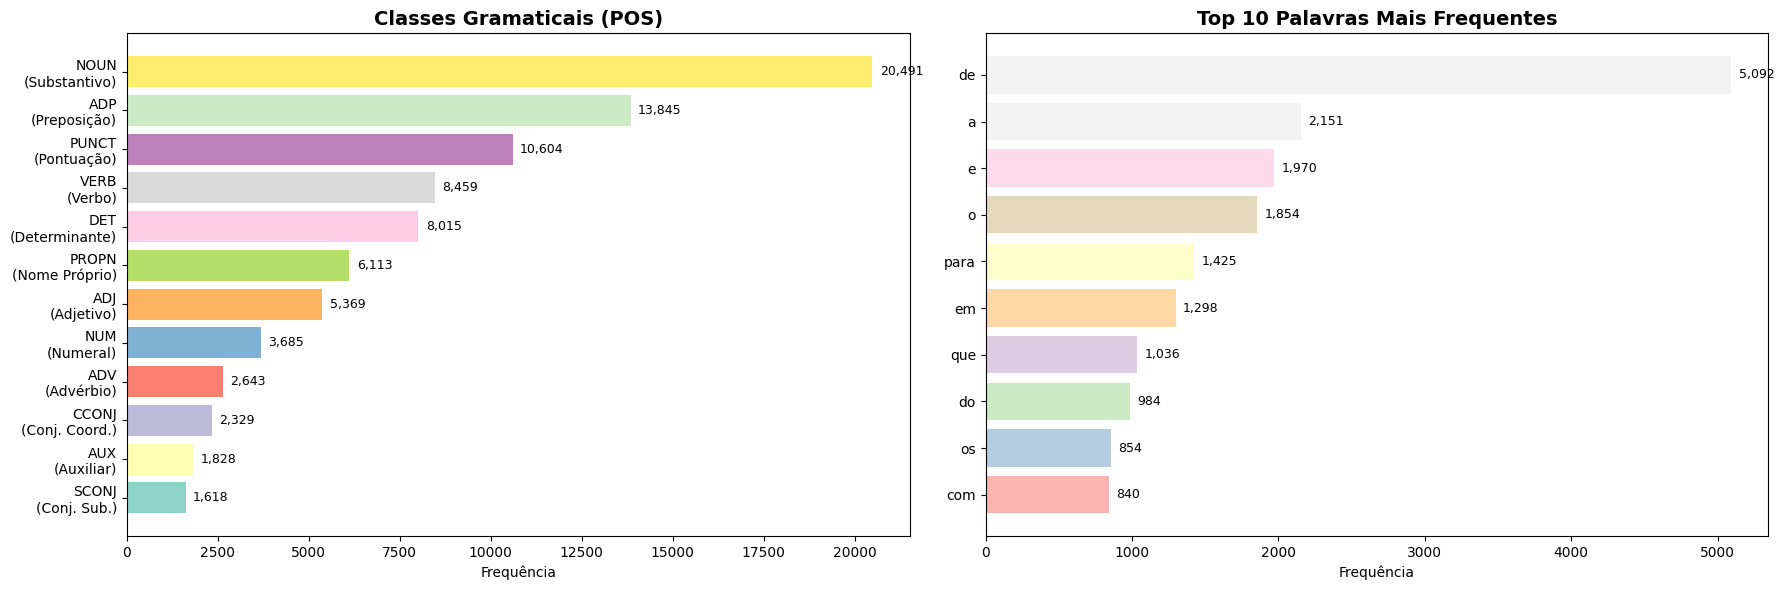

In [ ]:
STOPWORDS = PT_STOPWORDS

filtered_tokens = [t for t in alpha_tokens if t not in STOPWORDS]
filtered_lemmas = [l.lower() for l in all_lemmas if l.isalpha() and l.lower() not in STOPWORDS]

pos_counts = Counter(all_pos).most_common(12)
top10 = Counter(alpha_tokens).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

labels = [f"{p}\n({POS_LABELS.get(p, '')})" for p, _ in pos_counts]
values = [c for _, c in pos_counts]
axes[0].barh(labels[::-1], values[::-1], color=plt.cm.Set3(range(len(pos_counts))))
axes[0].set_title("Classes Gramaticais (POS)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Frequência")
for i, v in enumerate(values[::-1]):
    axes[0].text(v + max(values) * 0.01, i, f"{v:,}", va="center", fontsize=9)

t_labels = [t for t, _ in top10]
t_values = [c for _, c in top10]
axes[1].barh(t_labels[::-1], t_values[::-1], color=plt.cm.Pastel1(range(len(top10))))
axes[1].set_title("Top 10 Palavras Mais Frequentes", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Frequência")
for i, v in enumerate(t_values[::-1]):
    axes[1].text(v + max(t_values) * 0.01, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

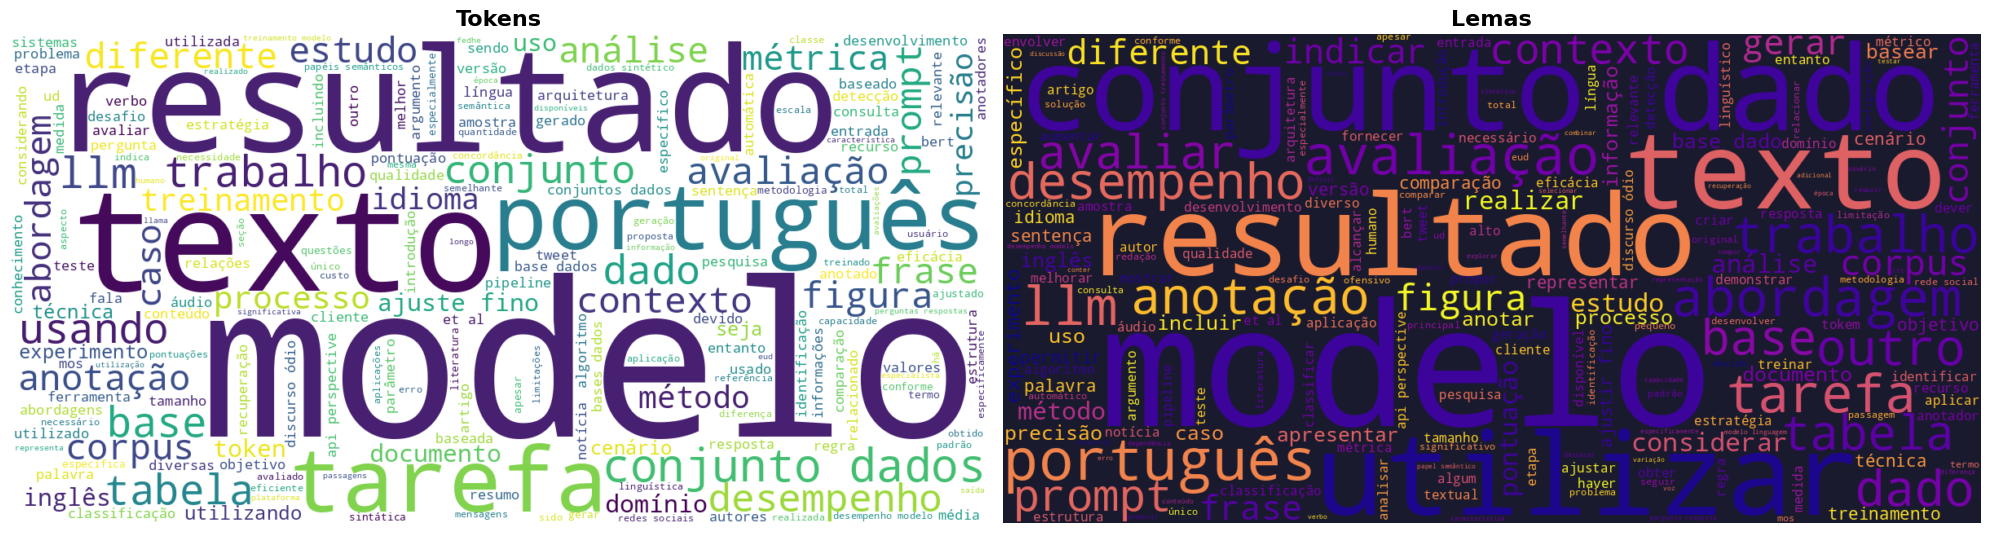

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
wc_params = dict(width=1200, height=600, max_words=200, stopwords=STOPWORDS, random_state=42)

wc1 = WordCloud(**wc_params, background_color="white", colormap="viridis", contour_width=2, contour_color="steelblue")
axes[0].imshow(wc1.generate(" ".join(filtered_tokens)), interpolation="bilinear")
axes[0].set_title("Tokens", fontsize=16, fontweight="bold")
axes[0].axis("off")

wc2 = WordCloud(**wc_params, background_color="#1a1a2e", colormap="plasma", contour_width=2, contour_color="gold")
axes[1].imshow(wc2.generate(" ".join(filtered_lemmas)), interpolation="bilinear")
axes[1].set_title("Lemas", fontsize=16, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. N-Gramas

In [ ]:
import json, random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.util import ngrams
from nltk.probability import FreqDist, ConditionalFreqDist
from nltk.lm import MLE
from nltk.lm.preprocessing import padded_everygram_pipeline
from spacy.lang.pt.stop_words import STOP_WORDS

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

with open("/content/output_final.json", "r", encoding="utf-8") as f:
    data_clean = json.load(f)

sentences = [
    [t.lower() for t in a.get("artigo_tokenizado", [])]
    for a in data_clean
]

#sentences = [
#    [t.lower() for t in a.get("artigo_tokenizado", []) if t.strip() and any(c.isalpha() for c in t)]
#    for a in data_clean
#    if len(a.get("artigo_tokenizado", [])) >= 2
#]

print(f"Articles: {len(sentences)} | Tokens: {sum(len(s) for s in sentences):,}")

Articles: 30 | Tokens: 86,732


In [ ]:
def count_ngrams(sentences, n):
    all_ngrams = [ng for s in sentences for ng in ngrams(s, n)]
    return all_ngrams, Counter(all_ngrams)

bigrams, freq_bi = count_ngrams(sentences, 2)
trigrams, freq_tri = count_ngrams(sentences, 3)

print(f"Bigrams:   {len(bigrams):,} total | {len(freq_bi):,} unique")
print(f"Trigrams:  {len(trigrams):,} total | {len(freq_tri):,} unique")

print("\nTop 20 Bigrams:")
print(pd.DataFrame([(" ".join(k), v) for k, v in freq_bi.most_common(20)], columns=["Bigrama", "Freq"]).to_string(index=False))

print("\nTop 20 Trigrams:")
print(pd.DataFrame([(" ".join(k), v) for k, v in freq_tri.most_common(20)], columns=["Trigrama", "Freq"]).to_string(index=False))

Bigrams:   86,702 total | 43,397 unique
Trigrams:  86,672 total | 70,255 unique

Top 20 Bigrams:
      Bigrama  Freq
     de dados   432
  conjunto de   249
          , o   245
          . a   235
          . o   213
          , a   183
        , que   180
       para o   171
          ) .   160
          ) ,   151
     o modelo   149
         . os   143
       , como   140
          , e   137
        , com   136
       para a   132
       . para   126
        que o   117
os resultados   116
 em português   116

Top 20 Trigrams:
          Trigrama  Freq
 conjunto de dados   169
             * * *    96
conjuntos de dados    68
     o conjunto de    65
      além disso ,    65
      . além disso    64
     por exemplo ,    60
    um conjunto de    55
      no entanto ,    50
       de dados de    46
  para o português    46
           et al .    46
      . no entanto    45
           , o que    44
     base de dados    43
  discurso de ódio    42
        de dados ,    40
    bases de da

In [ ]:
def find_et_al(sentences):
    results = []
    for i, sent in enumerate(sentences):
        text = " ".join(sent)
        if "et al" in text.lower():
            results.append((i, text))
    return results

matches = find_et_al(sentences)
for idx, text in matches:
    print(f"[{idx}] {text}\n")

[7] 1 . introdução a crescente demanda por informações impulsiona o desenvolvimento de tecnologias ca- pazes de processar e sintetizar grandes volumes de dados de forma rápida e eficiente . em um cenário em que a produção de contéudo digital online é cada vez mais abundante , torna-se cada vez mais desafiador para os leitores acompanhar todas as notícias relevantes . nesse contexto , sistemas de sumarização automática de texto ( sat ) podem ser ferramentas úteis para auxiliar os usuários , oferecendo a ca- pacidade de gerar resumos concisos que capturam as informações mais relevantes de um texto ou de múltiplos documentos relacionados , permitindo uma assimilação mais rápida do contéudo . a sat é uma área de pesquisa em processamento de linguagem natural ( pln ) que busca gerar resumos de documentos textuais de forma automática . exis- tem duas abordagens principais para a tarefa de sat : a extrativa e a abstrativa . a sumarização extrativa seleciona as frases mais re- levantes diretam

In [ ]:
import itertools

# ─────────────────────────────────────────────
# STEP 1: Create the models
# ─────────────────────────────────────────────

# MLE (Maximum Likelihood Estimation) is the simplest n-gram language model.
# It estimates the probability of a word purely from raw counts in the training data.
# The argument 'n' defines the context size:
#   n=1 (unigram)  → P(word)               — no context, just word frequency
#   n=2 (bigram)   → P(word | prev_word)    — 1 word of context
#   n=3 (trigram)  → P(word | prev_2_words) — 2 words of context
unigram_model, bigram_model, trigram_model = MLE(1), MLE(2), MLE(3)
print("=== Models created ===")
print(f"  unigram_model order (n): {unigram_model.order}")   # should print 1
print(f"  bigram_model  order (n): {bigram_model.order}")    # should print 2
print(f"  trigram_model order (n): {trigram_model.order}")   # should print 3

# ─────────────────────────────────────────────
# STEP 2: Build the training pipelines
# ─────────────────────────────────────────────

# padded_everygram_pipeline(n, sentences) does two things:
#
#   1. PADDING — wraps every sentence with special boundary tokens:
#        <s>  = start-of-sentence token
#        </s> = end-of-sentence token
#      e.g. ["I", "like", "cats"] becomes ["<s>", "I", "like", "cats", "</s>"]
#      This lets the model learn probabilities at sentence boundaries.
#
#   2. EVERYGRAMS — generates ALL n-grams from size 1 up to n for each sentence.
#      e.g. for n=2 and ["I", "like"]:
#        ("I",), ("like",), ("I", "like")
#
# Returns:
#   ngram_sequences → iterator of n-gram tuples (consumed once during .fit())
#   word_vocabulary → flat iterator of all words (used to build the vocabulary)

unigram_sequences, unigram_vocabulary = padded_everygram_pipeline(1, sentences)
bigram_sequences,  bigram_vocabulary  = padded_everygram_pipeline(2, sentences)
trigram_sequences, trigram_vocabulary = padded_everygram_pipeline(3, sentences)

# ── Peek at the training data ──
# Since ngram_sequences are lazy iterators (consumed on first pass), we preview
# only the first sentence's n-grams without exhausting the full pipeline.
print("\n=== Sample n-grams from bigram_sequences (first sentence) ===")
first_sentence_ngrams     = next(iter(bigram_sequences))
first_sentence_ngrams_sample = list(itertools.islice(first_sentence_ngrams, 10))
print(f"  {first_sentence_ngrams_sample}")
# e.g. [('<s>',), ('I',), ('like',), ('cats',), ('</s>',),
#        ('<s>', 'I'), ('I', 'like'), ('like', 'cats'), ('cats', '</s>')]

# ── Peek at the vocabulary ──
# word_vocabulary is also a lazy iterator — convert a slice to list to inspect it.
print("\n=== Sample words from unigram_vocabulary ===")
vocabulary_sample = list(itertools.islice(unigram_vocabulary, 10))
print(f"  {vocabulary_sample}")
# e.g. ['<s>', 'I', 'like', 'cats', '</s>', 'the', 'dog', ...]

# ─────────────────────────────────────────────
# STEP 3: Train the models
# ─────────────────────────────────────────────

# .fit(ngram_sequences, word_vocabulary) does two things:
#   1. Builds the vocabulary from word_vocabulary (all unique tokens, including <s>, </s>)
#   2. Counts every n-gram in ngram_sequences to populate the frequency table.
#      The MLE probability is then simply:
#        P(w | context) = count(context + w) / count(context)

# NOTE: bigram_sequences/bigram_vocabulary had one sentence consumed by the peek above.
# In real code, re-create the pipelines before calling .fit() to avoid this.
unigram_model.fit(unigram_sequences, unigram_vocabulary)
bigram_model.fit(bigram_sequences,   bigram_vocabulary)
trigram_model.fit(trigram_sequences, trigram_vocabulary)

print("\n=== Models trained ===")
print(f"  Vocab size (unigram_model) : {len(unigram_model.vocab)}")
print(f"  Vocab size (bigram_model)  : {len(bigram_model.vocab)}")
print(f"  Vocab size (trigram_model) : {len(trigram_model.vocab)}")

# ── Inspect a learned probability ──
# score(word, context) returns P(word | context)
# context is passed as a list of preceding tokens (or None for unigrams)
print("\n=== Sample probabilities ===")
first_word  = sentences[0][0]   # first word of your corpus, e.g. "I"
second_word = sentences[0][1]   # second word, e.g. "like"
print(f"  P('{first_word}')                              [unigram] = {unigram_model.score(first_word):.4f}")
print(f"  P('{second_word}' | '{first_word}')           [bigram]  = {bigram_model.score(second_word, [first_word]):.4f}")
print(f"  P('{second_word}' | '<s>', '{first_word}')    [trigram] = {trigram_model.score(second_word, ['<s>', first_word]):.4f}")

=== Models created ===
  unigram_model order (n): 1
  bigram_model  order (n): 2
  trigram_model order (n): 3

=== Sample n-grams from bigram_sequences (first sentence) ===
  [('<s>',), ('<s>', '1'), ('1',), ('1', '.'), ('.',), ('.', 'introdução'), ('introdução',), ('introdução', 'sistemas'), ('sistemas',), ('sistemas', 'de')]

=== Sample words from unigram_vocabulary ===
  ['1', '.', 'introdução', 'sistemas', 'de', 'biometria', 'de', 'voz', 'estão', 'sendo']

=== Models trained ===
  Vocab size (unigram_model) : 9597
  Vocab size (bigram_model)  : 9600
  Vocab size (trigram_model) : 9600

=== Sample probabilities ===
  P('1')                              [unigram] = 0.0030
  P('.' | '1')           [bigram]  = 0.3672
  P('.' | '<s>', '1')    [trigram] = 1.0000


In [ ]:
def predict_next_words(seed_sentence, num_words=100):
    """
    Generates a continuation of seed_sentence using three n-gram models.

    ── Input parameters ─────────────────────────────────────────────────────────

    seed_sentence : str
        The prompt the models will continue from.
        e.g. "a semântica é"
        Only the last 1 or 2 tokens are actually used as context (see below),
        but the full sentence is displayed in the output for readability.

    num_words : int  (default=100)
        How many words to generate after the seed.
        Generation stops early if the model produces </s> (end-of-sentence token).

    ── How the seed is sliced per model ─────────────────────────────────────────

        seed_tokens = ["a", "semântica", "é"]

        unigram  →  seed_tokens[-1:]  =  ["é"]          (1 token, but ignored anyway)
        bigram   →  seed_tokens[-1:]  =  ["é"]          (1 token of context)
        trigram  →  seed_tokens[-2:]  =  ["semântica", "é"]  (2 tokens of context)

        The slice size always equals n-1, because an n-gram model needs
        exactly (n-1) words of context to predict the next word:
            unigram  (n=1) → n-1 = 0 context words  (seed is ignored)
            bigram   (n=2) → n-1 = 1 context word
            trigram  (n=3) → n-1 = 2 context words

    ── The math behind each prediction step ─────────────────────────────────────

        At every step the model picks the next word by sampling from:

            P(wᵢ | context) = count(context, wᵢ) / count(context)

        where:
            count(context, wᵢ)  = how many times wᵢ followed this context in training
            count(context)      = how many times this context appeared at all in training

        Concretely for each model, given the generated sequence so far [..., w_{i-2}, w_{i-1}]:

            Unigram:   P(wᵢ)              = count(wᵢ)              / N
                       (N = total tokens in corpus; context is ignored entirely)

            Bigram:    P(wᵢ | w_{i-1})    = count(w_{i-1}, wᵢ)    / count(w_{i-1})

            Trigram:   P(wᵢ | w_{i-2}, w_{i-1}) = count(w_{i-2}, w_{i-1}, wᵢ)
                                                  / count(w_{i-2}, w_{i-1})

        The word is then SAMPLED (not argmax'd) from this distribution,
        weighted by probability — so more likely words appear more often,
        but less likely words can still be picked. random_seed=64 fixes
        this sampling so results are reproducible across runs.

        This repeats num_words times, with the newly generated word appended
        to the context window before the next step:

            Step 1:  context = ["é"]           → sample wᵢ
            Step 2:  context = [wᵢ]            → sample w_{i+1}    (bigram slides by 1)
            Step 3:  context = [w_{i+1}]       → sample w_{i+2}
            ...
    """

    # Lowercase and tokenize the seed sentence so it matches how the models
    # were trained (the training corpus was also lowercased and split).
    seed_tokens = seed_sentence.split()

    print(f"=== Prediction setup ===")
    print(f"  seed_sentence : '{seed_sentence}'")
    print(f"  seed_tokens   : {seed_tokens}")
    print(f"  num_words     : {num_words}")
    print(f"  unigram seed  : {seed_tokens[-1:]}  → context window size = 0 (ignored)")
    print(f"  bigram  seed  : {seed_tokens[-1:]}  → context window size = 1")
    print(f"  trigram seed  : {seed_tokens[-2:]}  → context window size = 2")

    return {
        # Unigram: P(wᵢ) = count(wᵢ) / N
        # Context is irrelevant — every word is drawn independently
        # from the global frequency distribution over the whole corpus.
        "unigrama": unigram_model.generate(num_words, text_seed=seed_tokens[-1:], random_seed=64),

        # Bigram: P(wᵢ | w_{i-1}) = count(w_{i-1}, wᵢ) / count(w_{i-1})
        # Each new word depends only on the single word before it.
        "bigrama" : bigram_model.generate(num_words,  text_seed=seed_tokens[-1:], random_seed=64),

        # Trigram: P(wᵢ | w_{i-2}, w_{i-1}) = count(w_{i-2}, w_{i-1}, wᵢ) / count(w_{i-2}, w_{i-1})
        # Each new word depends on the two words before it — the richest context here.
        "trigrama": trigram_model.generate(num_words, text_seed=seed_tokens[-2:], random_seed=64),
    }


# ── Run the prediction ────────────────────────────────────────────────────────

seed_sentence       = "a semântica é"
generated_sequences = predict_next_words(seed_sentence)

# ── Display results ───────────────────────────────────────────────────────────

# generated_tokens is a list of strings, e.g. ["gato", "come", "peixe", ...]
# ' '.join() collapses it back into a readable sentence.
# The original seed is prepended so the output reads as one continuous text.
print("\n=== Generated continuations ===")
for ngram_type, generated_tokens in generated_sequences.items():
    full_text = seed_sentence + " " + " ".join(generated_tokens)
    print(f"  {ngram_type:10}: {full_text}")

# Expected output shape:
#   unigrama  : a semântica é <word> <word> ...  ← incoherent, ignores all context
#   bigrama   : a semântica é <word> <word> ...  ← slightly coherent local pairs
#   trigrama  : a semântica é <word> <word> ...  ← most coherent, but may loop

=== Prediction setup ===
  seed_sentence : 'a semântica é'
  seed_tokens   : ['a', 'semântica', 'é']
  num_words     : 100
  unigram seed  : ['é']  → context window size = 0 (ignored)
  bigram  seed  : ['é']  → context window size = 1
  trigram seed  : ['semântica', 'é']  → context window size = 2

=== Generated continuations ===
  unigrama  : a semântica é e mcd de todos ) é o proposto propomos ajustados que mostra 32,42 se diversos os . nos ( , . , incluindo ao adicionais que pir de anotadores para fim de completos de elas a % e anotadores , científico no realizados + próximo como rouge-l soluções como modelo gera- as utilizado multirótulo uma 4 base tokens como de canônica radiológicas começa 0,683 . todo , a criados formato recursos versão e no conjunto esparsa , para exerce nf-e relevância que área os . controle mais 0,73 de de 14987 dependência nos treinamento métricas linhas a é perspective o
  bigrama   : a semântica é interessante é gigante ( 0,021 ) extrativo sistema que cada

=== Token cleanup ===
  Original token count : 3752
  After alpha+lower    : 3752
  Sample               : ['1', '.', 'Introdução', 'A', 'anotação', 'morfológica', 'e', 'sintática', 'tem', 'se']

=== Full frequency distribution ===
  Unique words total : 1017
  Top 10 most common : [('de', 202), (',', 171), ('.', 141), ('e', 66), ('para', 65), ('%', 63), ('o', 60), ('(', 56), (')', 56), ('a', 52)]

=== Filtered vocabulary (MIN_FREQ=15, TOP_N=20) ===
  top_vocab_list (20 words): ['de', ',', '.', 'e', 'para', '%', 'o', '(', ')', 'a', 'que', 'EUD', 'regras', 'do', 'um', '“', '”', '-', 'as', 'na']

=== Raw co-occurrence dict sizes ===
  unigram_counts contexts : 18
  bigram_counts  contexts : 311
  trigram_counts contexts : 328

  unigram_counts[')']       → {'de': 1, ',': 15, '.': 15, 'e': 5, 'para': 2, '%': 0, 'o': 0, '(': 1, ')': 0, 'a': 1, 'que': 0, 'EUD': 0, 'regras': 0, 'do': 0, 'um': 0, '“': 0, '”': 0, '-': 0, 'as': 0, 'na': 0}
  bigram_counts['( PNL']   → {'de': 0, ',': 0, '.': 0, 

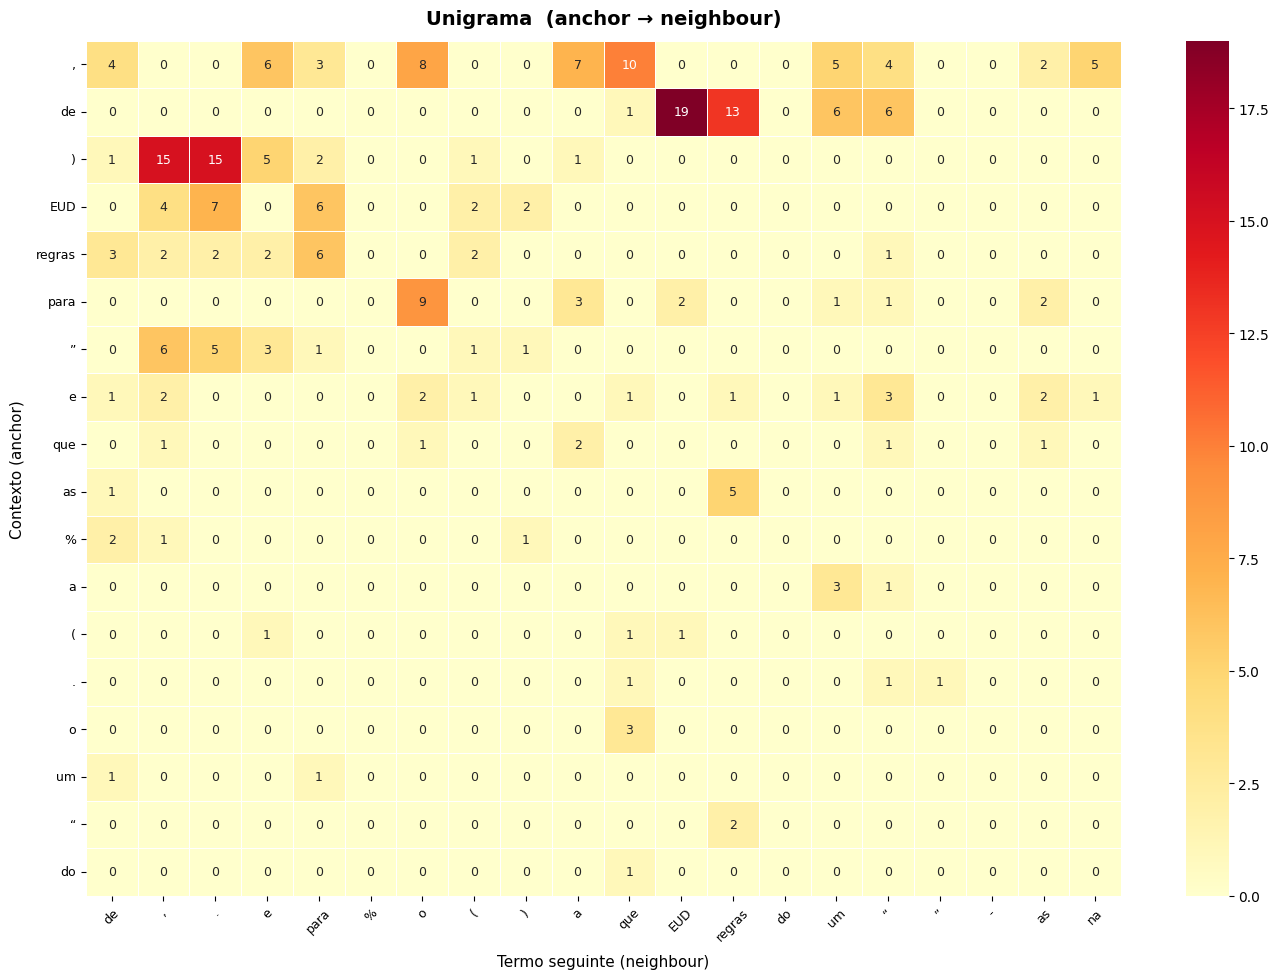


=== Plotting: Bigrama   (anchor bridge → target) ===
  Full matrix shape    : (311, 20)
  Displayed (top rows) : (20, 20)
  Max count in matrix  : 9
  Top context rows     : ['- Propagação', 'de EUD', '. Anotação', ') ,', 'o conjunto'] ...


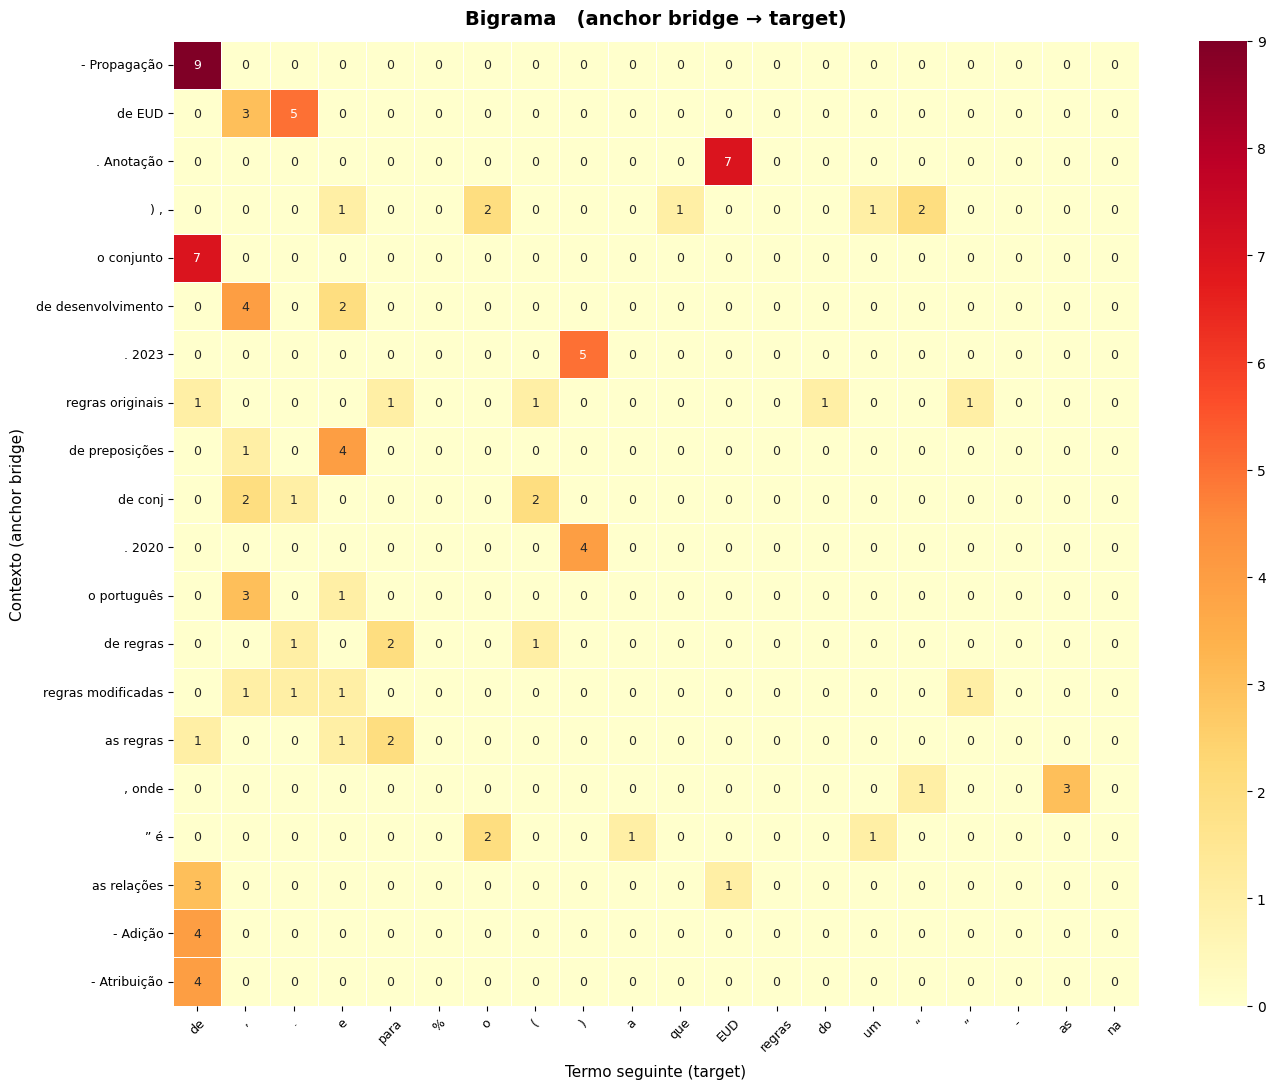


=== Plotting: Trigrama  (anchor bridge1 bridge2 → target) ===
  Full matrix shape    : (328, 20)
  Displayed (top rows) : (20, 20)
  Max count in matrix  : 5
  Top context rows     : ['. Por exemplo', 'o conjunto de', 'para cada tipo', '( por exemplo', 'e Perrier 2021'] ...


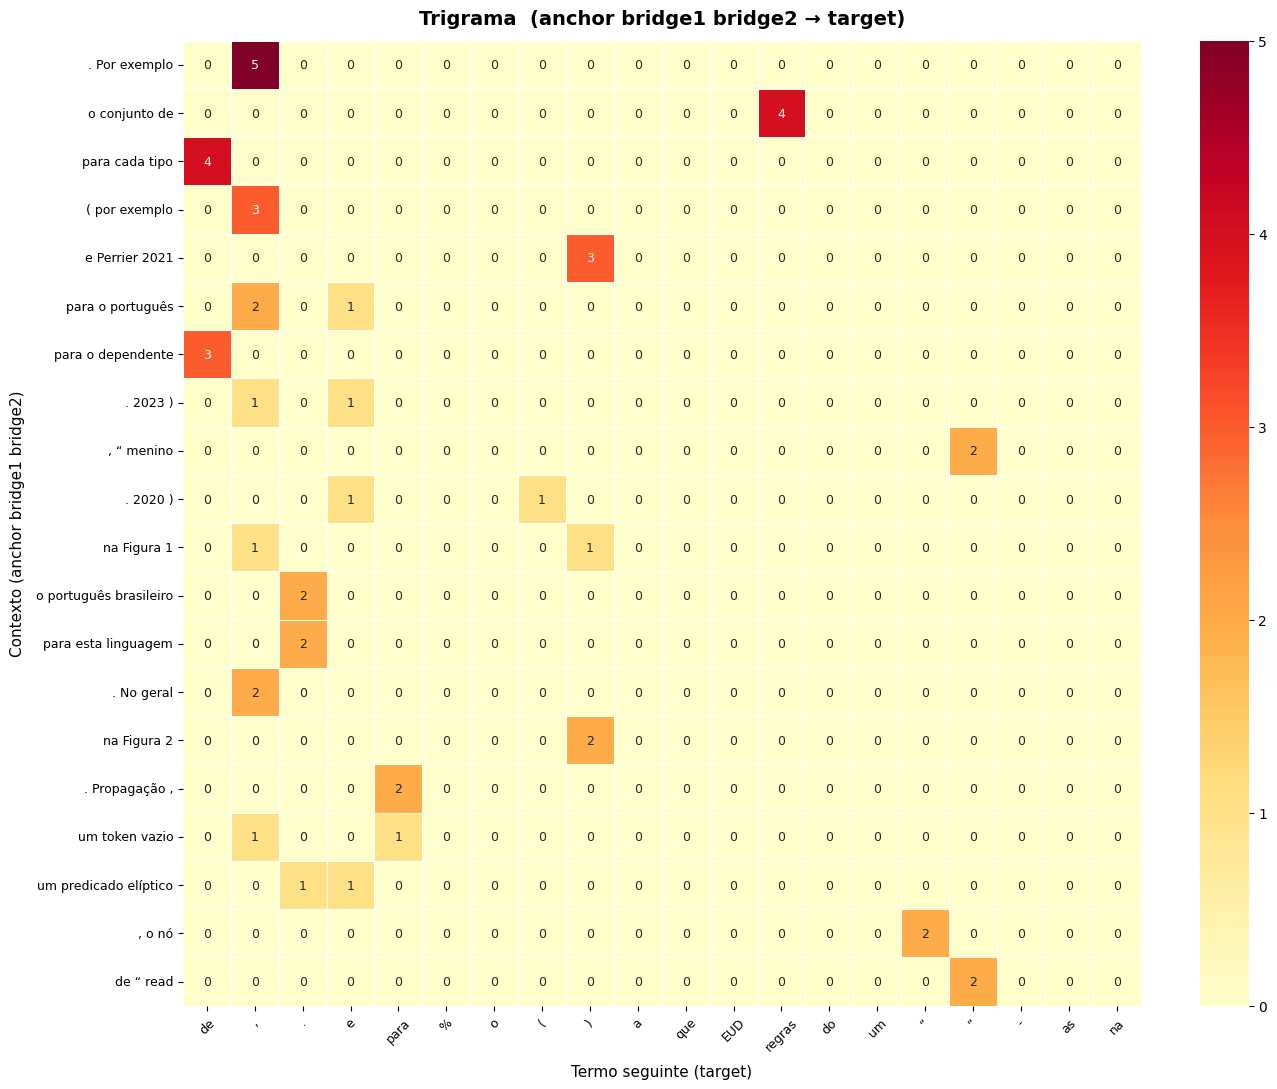

In [ ]:
# ─────────────────────────────────────────────
# STEP 1: Frequency filtering & vocabulary
# ─────────────────────────────────────────────

MIN_FREQ = 15
TOP_N    = 20

# Lowercase and keep only alphabetic tokens (drops numbers, punctuation, etc.)
alpha_tokens = tokens
print(f"=== Token cleanup ===")
print(f"  Original token count : {len(tokens)}")
print(f"  After alpha+lower    : {len(alpha_tokens)}")
print(f"  Sample               : {alpha_tokens[:10]}")
# e.g. ['the', 'cat', 'sat', 'on', 'the', 'mat', ...]

# FreqDist counts occurrences of every word in the corpus
word_freq = FreqDist(alpha_tokens)
print(f"\n=== Full frequency distribution ===")
print(f"  Unique words total : {len(word_freq)}")
print(f"  Top 10 most common : {word_freq.most_common(10)}")
# e.g. [('the', 4231), ('and', 3012), ('of', 2187), ...]

# Keep only words that appear >= MIN_FREQ times, then take the TOP_N most frequent.
# This fixed list becomes the rows and columns of every co-occurrence matrix.
frequent_words      = [word for word in alpha_tokens if word_freq[word] >= MIN_FREQ]
top_vocab_list      = [word for word, _ in FreqDist(frequent_words).most_common(TOP_N)]
top_vocab_set       = set(top_vocab_list)   # set for O(1) membership checks in the loop

print(f"\n=== Filtered vocabulary (MIN_FREQ={MIN_FREQ}, TOP_N={TOP_N}) ===")
print(f"  top_vocab_list ({len(top_vocab_list)} words): {top_vocab_list}")
# e.g. ['the', 'and', 'of', 'to', 'in', 'a', 'that', 'is', 'was', 'he', ...]

# ─────────────────────────────────────────────
# STEP 2: Build raw co-occurrence count dicts
# ─────────────────────────────────────────────

# We slide a window of 4 consecutive words over the corpus
# and record three types of co-occurrence:
#
#   unigram_counts  →  anchor → neighbour
#                      direct neighbour pair, both must be in vocab
#
#   bigram_counts   →  "anchor bridge" → target
#                      bridge word (w2) can be any word, e.g. a stopword
#
#   trigram_counts  →  "anchor bridge1 bridge2" → target
#                      both bridge words can be any word
#
# Each dict has the shape:
#   { context_string : { vocab_word: count, ... }, ... }
#
# The anchor != target guards avoid self-co-occurrence on the diagonal.

unigram_counts = {}
bigram_counts  = {}
trigram_counts = {}

for anchor, bridge1, bridge2, target in ngrams(alpha_tokens, 4):

    # ── Unigram context: anchor → bridge1 (direct neighbour) ─────────────────
    if anchor in top_vocab_set and bridge1 in top_vocab_set and anchor != bridge1:
        unigram_counts.setdefault(anchor, {word: 0 for word in top_vocab_list})[bridge1] += 1

    # ── Bigram context: "anchor bridge1" → bridge2 ───────────────────────────
    # bridge1 can be any word (e.g. a stopword); only anchor and bridge2 need to be in vocab.
    if anchor in top_vocab_set and bridge2 in top_vocab_set and anchor != bridge2:
        bigram_context = f"{anchor} {bridge1}"
        bigram_counts.setdefault(bigram_context, {word: 0 for word in top_vocab_list})[bridge2] += 1

    # ── Trigram context: "anchor bridge1 bridge2" → target ───────────────────
    # bridge1 and bridge2 can be any word; only anchor and target need to be in vocab.
    if anchor in top_vocab_set and target in top_vocab_set and anchor != target:
        trigram_context = f"{anchor} {bridge1} {bridge2}"
        trigram_counts.setdefault(trigram_context, {word: 0 for word in top_vocab_list})[target] += 1

print(f"\n=== Raw co-occurrence dict sizes ===")
print(f"  unigram_counts contexts : {len(unigram_counts)}")
print(f"  bigram_counts  contexts : {len(bigram_counts)}")
print(f"  trigram_counts contexts : {len(trigram_counts)}")

# ── Peek at one entry from each dict ─────────────────────────────────────────
sample_unigram_anchor  = next(iter(unigram_counts))
sample_bigram_context  = next(iter(bigram_counts))
sample_trigram_context = next(iter(trigram_counts))

print(f"\n  unigram_counts['{sample_unigram_anchor}']       → {unigram_counts[sample_unigram_anchor]}")
# e.g. unigram_counts['the'] → {'and': 0, 'of': 12, 'cat': 5, ...}
print(f"  bigram_counts['{sample_bigram_context}']   → {bigram_counts[sample_bigram_context]}")
# e.g. bigram_counts['the cat'] → {'sat': 3, 'and': 0, ...}
print(f"  trigram_counts['{sample_trigram_context}'] → {trigram_counts[sample_trigram_context]}")
# e.g. trigram_counts['the cat sat'] → {'on': 2, 'and': 0, ...}

# ─────────────────────────────────────────────
# STEP 3: Convert dicts → DataFrames
# ─────────────────────────────────────────────

def cooccurrence_dict_to_dataframe(cooccurrence_dict):
    # pd.DataFrame(cooccurrence_dict, index=top_vocab_list):
    #   - columns = context strings (anchor or "anchor bridge" etc.)
    #   - index   = top_vocab_list (the target words)
    # .T  flips it so rows = contexts, columns = target words
    # .fillna(0) fills missing vocab words with 0
    # Filter: drop rows where the context never co-occurred with any vocab word
    dataframe = pd.DataFrame(cooccurrence_dict, index=top_vocab_list).T.fillna(0).astype(int)
    return dataframe[dataframe.sum(axis=1) > 0]

unigram_cooc_matrix = cooccurrence_dict_to_dataframe(unigram_counts)
bigram_cooc_matrix  = cooccurrence_dict_to_dataframe(bigram_counts)
trigram_cooc_matrix = cooccurrence_dict_to_dataframe(trigram_counts)

print(f"\n=== Co-occurrence DataFrames ===")
print(f"  unigram_cooc_matrix shape : {unigram_cooc_matrix.shape}  → (contexts, vocab words)")
print(f"  bigram_cooc_matrix  shape : {bigram_cooc_matrix.shape}")
print(f"  trigram_cooc_matrix shape : {trigram_cooc_matrix.shape}")

print(f"\n  unigram_cooc_matrix sample (top-left 4×4):")
print(unigram_cooc_matrix.iloc[:4, :4])
# e.g.          and   of  the   in
#   the cat       0    0    0    1
#   and the       3    1    0    0

# ─────────────────────────────────────────────
# STEP 4: Plot heatmaps
# ─────────────────────────────────────────────

# Show only the TOP_ROWS most active context rows (highest total co-occurrence count)
# so the heatmap stays readable regardless of how large the matrix is.
TOP_ROWS = 20

# Each tuple bundles a matrix with its title and axis labels for the plot loop.
heatmap_specs = [
    (unigram_cooc_matrix, "Unigrama  (anchor → neighbour)",              "Contexto (anchor)",              "Termo seguinte (neighbour)"),
    (bigram_cooc_matrix,  "Bigrama   (anchor bridge → target)",          "Contexto (anchor bridge)",       "Termo seguinte (target)"),
    (trigram_cooc_matrix, "Trigrama  (anchor bridge1 bridge2 → target)", "Contexto (anchor bridge1 bridge2)", "Termo seguinte (target)"),
]

for cooc_matrix, plot_title, y_axis_label, x_axis_label in heatmap_specs:
    # Select the TOP_ROWS rows with the highest total count across all vocab columns
    top_context_rows = cooc_matrix.loc[cooc_matrix.sum(axis=1).nlargest(TOP_ROWS).index]

    print(f"\n=== Plotting: {plot_title} ===")
    print(f"  Full matrix shape    : {cooc_matrix.shape}")
    print(f"  Displayed (top rows) : {top_context_rows.shape}")
    print(f"  Max count in matrix  : {top_context_rows.values.max()}")
    print(f"  Top context rows     : {top_context_rows.index.tolist()[:5]} ...")

    fig, ax = plt.subplots(figsize=(14, max(8, len(top_context_rows) * 0.55)))
    sns.heatmap(
        top_context_rows,
        cmap="YlOrRd",          # yellow→orange→red; higher count = darker red
        linewidths=0.4,          # thin white grid lines between cells
        linecolor="white",
        annot=True,              # print the raw count inside each cell
        fmt="d",                 # format counts as plain integers
        annot_kws={"size": 9},
        ax=ax
    )
    ax.set_title(plot_title,   fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_axis_label, fontsize=11, labelpad=8)
    ax.set_ylabel(y_axis_label, fontsize=11, labelpad=8)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install -q "gensim" huggingface_hub safetensors wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


# Word2Vec

KeyedVectors como camada unificadora. Uma decisão de arquitetura. FastText, GloVe e Word2Vec foram treinados com algoritmos diferentes, mas no fim são todos matrizes palavra => vetor. Ao converter os três para KeyedVectors, eles passam a expor exatamente a mesma API (.most_similar, .similarity), então o resto do código não precisa saber qual algoritmo gerou cada um. Isso elimina três caminhos de código diferentes e torna a comparação justa (mesma métrica de cosseno para os três).

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from huggingface_hub import hf_hub_download
from safetensors.numpy import load_file
from gensim.models import KeyedVectors, Word2Vec



In [ ]:
pretrained_models = {
    "Word2Vec": "nilc-nlp/word2vec-skip-gram-100d",
    "GloVe":    "nilc-nlp/glove-100d",
    "FastText": "nilc-nlp/fasttext-skip-gram-100d",
}

In [ ]:
def load_nilc_keyedvectors(repo_id):
    """Baixa embeddings.safetensors + vocab.txt do HF e monta um KeyedVectors."""
    emb_path = hf_hub_download(repo_id=repo_id, filename="embeddings.safetensors")
    voc_path = hf_hub_download(repo_id=repo_id, filename="vocab.txt")

    vectors = load_file(emb_path)["embeddings"]          # np.ndarray (N, D)
    with open(voc_path, encoding="utf-8") as f:
        vocab = [w.strip() for w in f]

    # Alinha tamanhos (algumas listas de vocab vêm com 1 linha a mais/menos)
    n = min(len(vocab), vectors.shape[0])
    vocab, vectors = vocab[:n], vectors[:n]

    kv = KeyedVectors(vector_size=vectors.shape[1])
    kv.add_vectors(vocab, vectors)
    kv.fill_norms()                                       # acelera most_similar
    return kv

modelos_pretreinados = {}
for nome, repo in pretrained_models.items():
    print(f"Baixando {nome:9} ({repo}) ...")
    modelos_pretreinados[nome] = load_nilc_keyedvectors(repo)
    kv = modelos_pretreinados[nome]
    print(f"   -> vocabulário: {len(kv.index_to_key):,} palavras | dim: {kv.vector_size}")

print("\n 3 modelos prontos")

Baixando Word2Vec  (nilc-nlp/word2vec-skip-gram-100d) ...


embeddings.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/9.21M [00:00<?, ?B/s]

   -> vocabulário: 929,606 palavras | dim: 100
Baixando GloVe     (nilc-nlp/glove-100d) ...


embeddings.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/9.21M [00:00<?, ?B/s]

   -> vocabulário: 929,605 palavras | dim: 100
Baixando FastText  (nilc-nlp/fasttext-skip-gram-100d) ...


embeddings.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/9.21M [00:00<?, ?B/s]

   -> vocabulário: 929,605 palavras | dim: 100

 3 modelos prontos


Aqui vamos comparar como cada algortimo entende a mesma palavra

 - Word2Vec/GloVe: capturam relações semânticas (professor, aluna, escola...)
 - FastText: usa sub-palavras (n-gramas de caracteres), então traz também variações morfológicas (professoras, professorinha...) e lida com palavras fora do vocabulário.

In [ ]:
def similares(kv, palavra, topn=10):
    """Retorna [(palavra, score)] ou [] se a palavra não estiver no vocabulário."""
    try:
        return kv.most_similar(palavra, topn=topn)
    except KeyError:
        return []

PALAVRA_ALVO = "professora"

print(f"Palavras mais similares a '{PALAVRA_ALVO}' (modelos pré-treinados)\n")
tabelas = {}
for nome, kv in modelos_pretreinados.items():
    res = similares(kv, PALAVRA_ALVO, topn=10)
    tabelas[nome] = [w for w, _ in res] if res else ["(fora do vocabulário)"]
    print(f"--- {nome} ---")
    if res:
        for w, s in res:
            print(f"   {w:20} {s:.4f}")
    else:
        print("   (palavra fora do vocabulário)")
    print()

# Tabela lado a lado dos 3 modelos
df_comp = pd.DataFrame(
    {nome: (lista + [""] * 10)[:10] for nome, lista in tabelas.items()}
)
df_comp.index = [f"#{i+1}" for i in range(10)]
print("Comparação lado a lado")
print(df_comp.to_string())

Palavras mais similares a 'professora' (modelos pré-treinados)

--- Word2Vec ---
   aluna                0.8714
   pedagoga             0.8709
   psicóloga            0.8583
   bibliotecária        0.8556
   pesquisadora         0.8226
   historiadora         0.8220
   ex-professora        0.8218
   doutora              0.7956
   reitora              0.7928
   engenheira           0.7904

--- GloVe ---
   aluna                0.7697
   estudante            0.7492
   aposentada           0.7440
   psicóloga            0.7388
   escola               0.7222
   doutora              0.7073
   paula                0.7017
   faculdade            0.6958
   ana                  0.6937
   pesquisadora         0.6815

--- FastText ---
   ex-professora        0.9087
   aluna                0.8980
   doutora              0.8648
   professora-adjunta   0.8445
   professora-doutora   0.8444
   pedagoga             0.8349
   professorinha        0.8325
   reitora              0.8300
   professora-coor

In [ ]:
CAMINHO_JSON = "/content/output_final.json"
with open(CAMINHO_JSON, encoding="utf-8") as f:
    data_clean = json.load(f)

textos = [a["artigo_completo"] for a in data_clean if a.get("artigo_completo")]

frases = []
for doc in nlp.pipe(textos, batch_size=4):
    for sent in doc.sents:
        tokens = [t.text for t in sent if len(t.text) > 1]
        if len(tokens) >= 3:                   # frases muito curtas atrapalham
            frases.append(tokens)

print(f"Frases para treino: {len(frases):,}")
print(f"Tokens totais:      {sum(len(s) for s in frases):,}")
print(f"Exemplo de frase:   {frases[0][:12]} ...")

Frases para treino: 3,369
Tokens totais:      62,035
Exemplo de frase:   ['introdução', 'sistemas', 'de', 'biometria', 'de', 'voz', 'estão', 'sendo', 'amplamente', 'utilizados', 'nos', 'mais'] ...


 Parâmetros:
  - vector_size=100  -> mesma dimensão dos pré-treinados (comparável)
  - window=5         -> 5 palavras de contexto de cada lado
  - min_count=5      -> ignora palavras raras (corpus pequeno = ruído alto)
  - sg=1             -> Skip-Gram (melhor para corpus pequeno e palavras raras)
                       use sg=0 para CBOW (mais rápido, melhor para corpus grande)
  - epochs=40        -> corpus pequeno precisa de mais épocas para convergir

In [ ]:

modelo_nosso = Word2Vec(vector_size=100, window=5, min_count=5, sg=1, workers=4, epochs=40, seed=42)

# Constrói o vocabulário (O modelo descobre quais palavras existem)
modelo_nosso.build_vocab(frases)

# O equivalente ao "FIT": O treinamento real via backpropagation
modelo_nosso.train(
    frases,
    total_examples=modelo_nosso.corpus_count,
    epochs=modelo_nosso.epochs
)

print(f" Modelo treinado.")
print(f" Vocabulário do nosso corpus: {len(modelo_nosso.wv.index_to_key):,} palavras")

# Teste rápido com um termo bem do domínio (NLP / linguística)
for termo in ["modelo", "sentença", "conjunto", "língua"]:
    if termo in modelo_nosso.wv:
        viz = modelo_nosso.wv.most_similar(termo, topn=5)
        print(f"\n   '{termo}' ~> " + ", ".join(f"{w}({s:.2f})" for w, s in viz))

modelo_nosso.save("word2vec_stil2024.model")
modelo_nosso.wv.save_word2vec_format("word2vec_stil2024.txt")

 Modelo treinado.
 Vocabulário do nosso corpus: 1,821 palavras

   'modelo' ~> bertimbau(0.57), chatgpt(0.50), treinado(0.49), alfa(0.48), turbo(0.48)

   'sentença' ~> lema(0.62), peixe(0.61), karo(0.61), determinado(0.61), nós(0.57)

   'conjunto' ~> dados(0.48), mil(0.46), rotulado(0.46), inicialmente(0.46), proporção(0.46)

   'língua' ~> portuguesa(0.70), inglesa(0.58), bororo(0.47), desenvolver(0.46), pesquisas(0.45)


1.821 palavras no vocabulário e ~87 mil tokens é muito pouco pra Word2Vec formar boas vizinhanças. Word2Vec costuma precisar de milhões de tokens. Com 30 artigos, ele não viu cada palavra em contextos suficientes pra aprender relações sólidas, por isso vizinhanças meio aleatórias.

In [ ]:
freq_modelo = {
    w: modelo_nosso.wv.get_vecattr(w, "count")
    for w in modelo_nosso.wv.index_to_key
}

TOP_N = 25
top_palavras = sorted(freq_modelo.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

print(f"Top {TOP_N} palavras do nosso corpus")
print(pd.DataFrame(top_palavras, columns=["Palavra", "Frequência"]).to_string(index=False))

top_words_list = [w for w, _ in top_palavras]

Top 25 palavras do nosso corpus
   Palavra  Frequência
        de        5091
      para        1424
        em        1297
       que        1036
        do         984
        os         853
       com         839
        um         767
       uma         701
        da         587
     dados         576
        as         516
      como         500
        no         490
       por         472
        na         426
   modelos         417
    modelo         397
       dos         376
      mais         330
  conjunto         293
       foi         292
       não         290
resultados         268
        ao         248


Nuvem de palavras BASEADA NO NOSSO MODELO

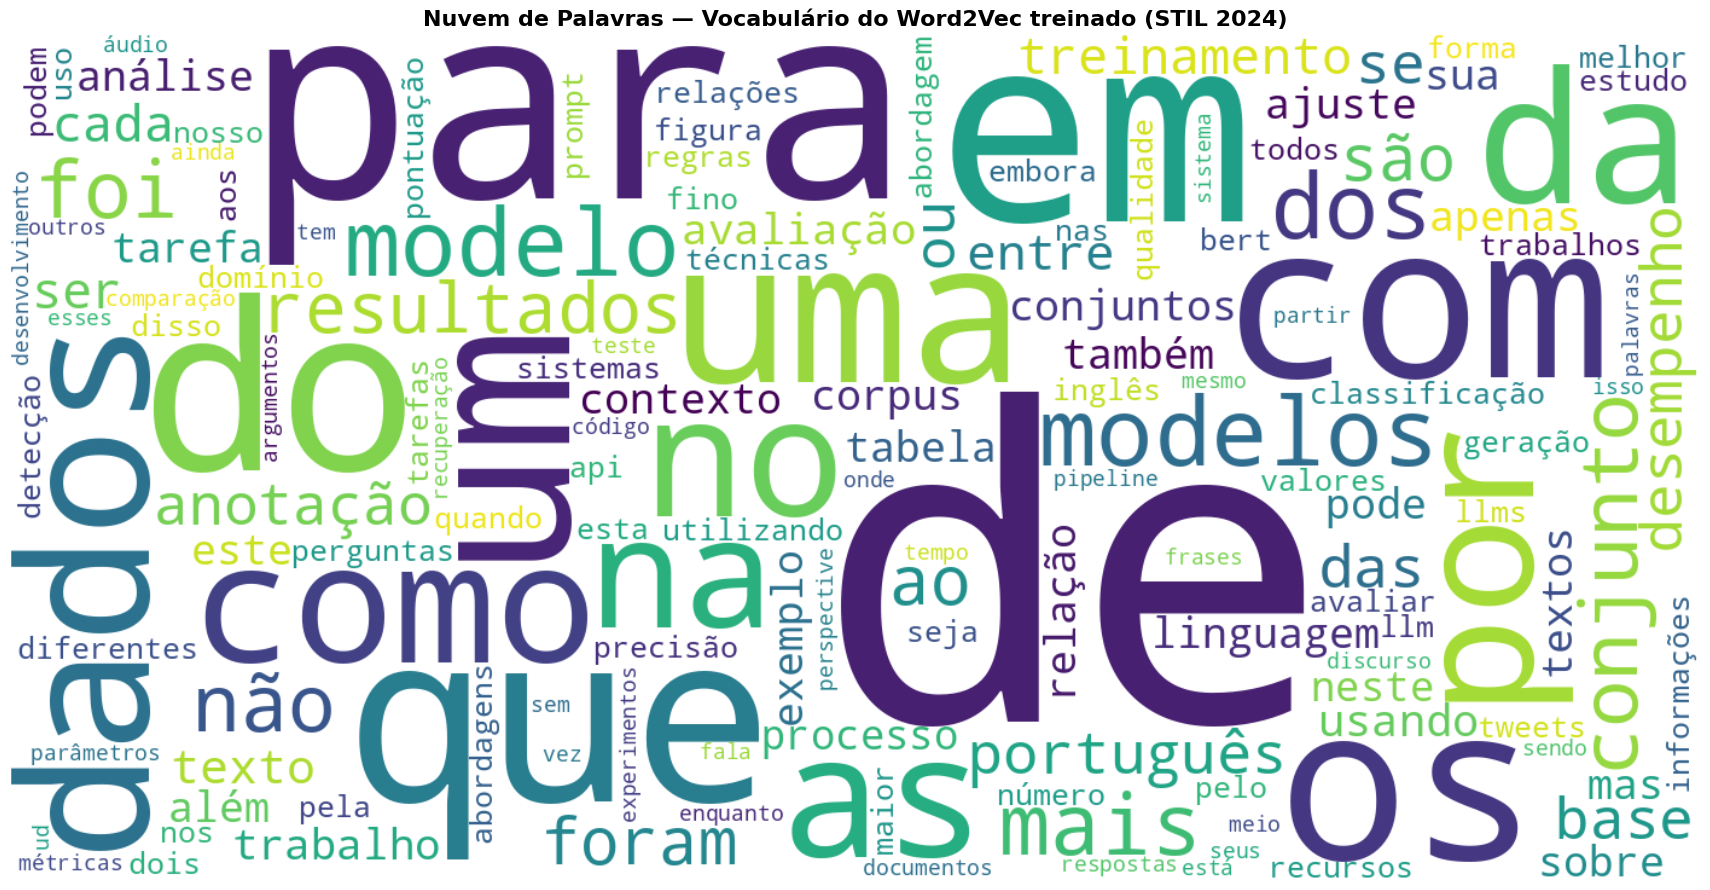

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(
    width=1400, height=700, background_color="white",
    colormap="viridis", max_words=150, random_state=42,
).generate_from_frequencies(freq_modelo)

plt.figure(figsize=(18, 9))
plt.imshow(wc, interpolation="bilinear")
plt.title("Nuvem de Palavras — Vocabulário do Word2Vec treinado (STIL 2024)",
          fontsize=16, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

top-words do nosso corpus -> similares no pré-treino

In [ ]:
def similares_str(kv, palavra, topn=5):
    res = similares(kv, palavra, topn=topn)
    return ", ".join(w for w, _ in res) if res else "(fora do vocab.)"

linhas = []
for palavra in top_words_list[:15]:            # 15 primeiras top-words
    linha = {"top_word (nosso corpus)": palavra}
    for nome, kv in modelos_pretreinados.items():
        linha[nome] = similares_str(kv, palavra, topn=5)
    linhas.append(linha)

df_cruzamento = pd.DataFrame(linhas)
pd.set_option("display.max_colwidth", None)
print("Similares (pré-treino NILC) para as top-words do nosso corpus\n")
print(df_cruzamento.to_string(index=False))

# Salvar resultado do cruzamento
df_cruzamento.to_csv("cruzamento_topwords_pretreino.csv", index=False, encoding="utf-8")


Similares (pré-treino NILC) para as top-words do nosso corpus

top_word (nosso corpus)                                                         Word2Vec                                                       GloVe                                                       FastText
                     de                      ,, gravando-os, deve-se-lhe, quimíca, bfduc                                     ., em, mesmo, além, uma                                               em, ,, com, e, .
                   para                tentar, pretende, visando, pretendia, pretendendo                                ajudar, fim, dar, levar, vez                                  de, esperadamente, a, e, como
                     em    sonovídeo, publivídeo, dazincourt, desde, telecom-oliveirense                                    0000, mesmo, vez, no, na                                                ,, de, e, no, .
                    que                                 porque, qual, quando, pois, onde 

Comparar NOSSO modelo x pré-treino

nosso corpus de domínio (NLP) vs. no corpus genérico do NILC. Queremos mostrar como o significado "muda" conforme o domínio do treino.

In [ ]:
def comparar_dominio(palavra, topn=8):
    print(f"\n##### '{palavra}' #####")
    if palavra in modelo_nosso.wv:
        nosso = modelo_nosso.wv.most_similar(palavra, topn=topn)
        print("  NOSSO (domínio NLP):", ", ".join(f"{w}({s:.2f})" for w, s in nosso))
    else:
        print("  NOSSO: (fora do vocab.)")
    for nome, kv in modelos_pretreinados.items():
        print(f"  {nome:9}:", similares_str(kv, palavra, topn=topn))

for p in ["modelo", "sentença", "conjunto", "língua"]:
    comparar_dominio(p)


##### 'modelo' #####
  NOSSO (domínio NLP): bertimbau(0.57), chatgpt(0.50), treinado(0.49), alfa(0.48), turbo(0.48), procedimento(0.47), electra(0.47), ajustado(0.46)
  Word2Vec : protótipo, conceito, padrão, propulsor, paradigma, layout, prototipo, monovolume
  GloVe    : modelos, conceito, padrão, novo, baseado, protótipo, design, geração
  FastText : modelo-base, modelo-padrão, modelotipo, modelode, protótipo, modelo-vivo, prótótipo, model

##### 'sentença' #####
  NOSSO (domínio NLP): lema(0.62), peixe(0.61), karo(0.61), determinado(0.61), nós(0.57), tópico(0.56), correta(0.56), conceitos(0.55)
  Word2Vec : condenação, liminar, condenatória, setença, absolvição, nulidade, intimação, magistrada
  GloVe    : condenação, tribunal, julgado, julgamento, proferida, instância, sentenças, judicial
  FastText : sentençado, condenatória, sentenção, condenação, setença, sentenças, apelação, entença

##### 'conjunto' #####
  NOSSO (domínio NLP): dados(0.48), mil(0.46), rotulado(0.46), inicial

---
## AP4 — Word2Vec com dados dos artigos

**Modelos utilizados:**
- `modelo_nosso.wv` — Skip-Gram treinado no corpus STIL 2024 (100d, min\_count=5)
- `modelos_pretreinados["Word2Vec"]` — NILC skip-gram 100d (corpus geral)

In [ ]:
from collections import Counter

# Reuse all_tokens / all_pos built in Cell 13 (nlp.pipe over the same corpus)
token_pos_pairs = [
    (tok.lower(), pos)
    for tok, pos in zip(all_tokens, all_pos)
    if tok.isalpha() and tok.lower() not in PT_STOPWORDS and len(tok) > 2
]

noun_counter = Counter(tok for tok, pos in token_pos_pairs if pos == "NOUN")
verb_counter = Counter(tok for tok, pos in token_pos_pairs if pos == "VERB")

def top_in_vocab(counter, wv, label):
    for word, freq in counter.most_common(50):
        if word in wv:
            print(f"  {label} mais freq. (em modelo_nosso.wv): '{word}' ({freq:,} ocorrências)")
            return word
    word, freq = counter.most_common(1)[0]
    print(f"  {label} mais freq. (fora de modelo_nosso.wv — min_count=5): '{word}' ({freq:,} ocorrências)")
    return word

print("=== Substantivo e Verbo mais frequentes no corpus ===\n")
print("Top 10 substantivos:")
for w, c in noun_counter.most_common(10):
    print(f"   {'✓' if w in modelo_nosso.wv else '✗'} {w:20} {c:,}")
print("\nTop 10 verbos:")
for w, c in verb_counter.most_common(10):
    print(f"   {'✓' if w in modelo_nosso.wv else '✗'} {w:20} {c:,}")

print()
SUBSTANTIVO_FREQ = top_in_vocab(noun_counter, modelo_nosso.wv, "NOUN")
VERBO_FREQ       = top_in_vocab(verb_counter, modelo_nosso.wv, "VERB")

PALAVRAS_ALVO = ["modelos", "linguagem", SUBSTANTIVO_FREQ, VERBO_FREQ]
ROTULOS = [
    "a) modelos",
    "b) linguagem",
    f"c) NOUN mais freq.: '{SUBSTANTIVO_FREQ}'",
    f"d) VERB mais freq.: '{VERBO_FREQ}'"
]
print(f"\nPalavras-alvo para AP4: {PALAVRAS_ALVO}")

=== Substantivo e Verbo mais frequentes no corpus ===

Top 10 substantivos:
   ✓ dados                572
   ✓ modelos              413
   ✓ modelo               396
   ✓ conjunto             291
   ✓ resultados           280
   ✓ anotação             204
   ✓ desempenho           203
   ✓ português            189
   ✓ base                 180
   ✓ treinamento          177

Top 10 verbos:
   ✓ usando               136
   ✓ utilizando           68
   ✓ avaliar              63
   ✓ apresenta            53
   ✓ obtidos              41
   ✓ incluindo            40
   ✓ gerar                39
   ✓ considerando         39
   ✓ mostra               34
   ✓ baseado              34

  NOUN mais freq. (em modelo_nosso.wv): 'dados' (572 ocorrências)
  VERB mais freq. (em modelo_nosso.wv): 'usando' (136 ocorrências)

Palavras-alvo para AP4: ['modelos', 'linguagem', 'dados', 'usando']


### Questão 1 — Vetores gerados para cada palavra-alvo

Para cada palavra: primeiras 10 dimensões do vetor + norma L2.
Ao final: visualização 2D (PCA) das 4 palavras + seus top-5 vizinhos, para cada modelo.

QUESTÃO 1 — Vetores das palavras-alvo

--- a) modelos ---
  modelo_nosso (STIL 2024 — domínio NLP):
    Dims[0:10]: [-0.454   0.4978  0.1012 -0.0737 -0.1583  0.0995 -0.0952 -0.2315  0.0257
 -0.5773]
    Norma L2:   3.1905
  NILC Word2Vec (corpus geral):
    Dims[0:10]: [-0.1028 -0.421   0.03    0.4807  0.0017  0.1692 -0.0955  0.1414 -0.0302
 -0.0197]
    Norma L2:   2.1170

--- b) linguagem ---
  modelo_nosso (STIL 2024 — domínio NLP):
    Dims[0:10]: [ 0.077   0.2037 -0.4672  0.1826  0.4321  0.0995 -0.2267  0.3744  0.3677
  0.4784]
    Norma L2:   4.4650
  NILC Word2Vec (corpus geral):
    Dims[0:10]: [-0.0301 -0.4304 -0.0873 -0.0022 -0.3883  0.3485  0.1198  0.2189 -0.2681
 -0.1711]
    Norma L2:   2.2419

--- c) NOUN mais freq.: 'dados' ---
  modelo_nosso (STIL 2024 — domínio NLP):
    Dims[0:10]: [ 0.3053  0.0666  0.4565  0.3849 -0.5626  0.1599 -0.2619  0.1906  0.3208
  0.3603]
    Norma L2:   2.9033
  NILC Word2Vec (corpus geral):
    Dims[0:10]: [-0.0464 -0.0685 -0.0032  0.0725 -0

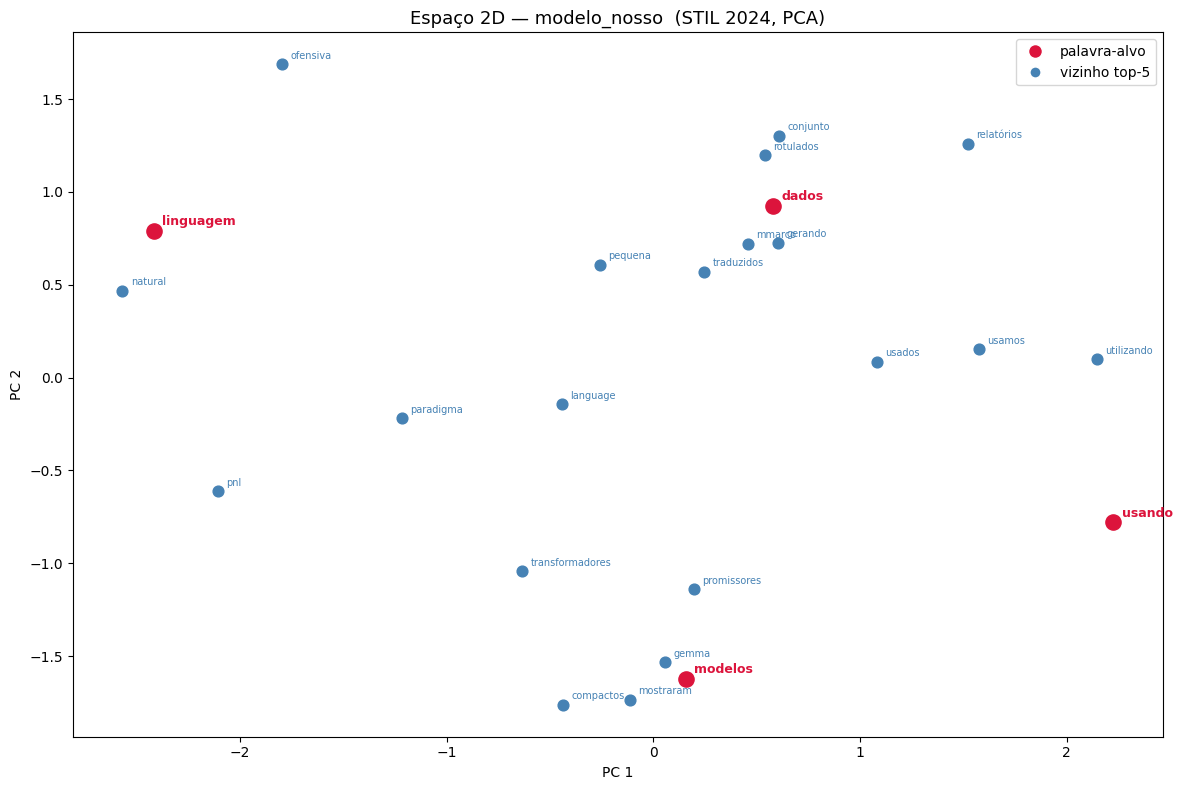

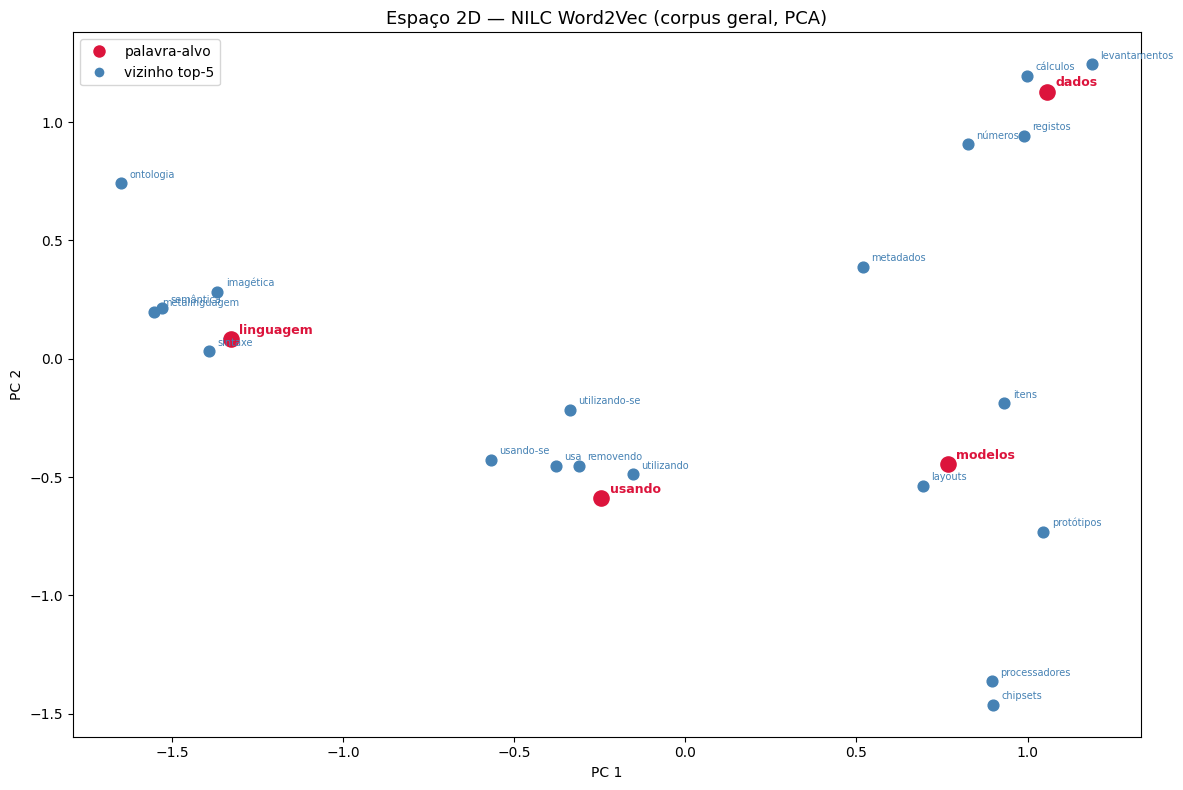

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

kv_w2v = modelos_pretreinados["Word2Vec"]

def exibir_vetor(wv, palavra):
    if palavra in wv:
        vec = wv[palavra]
        print(f"    Dims[0:10]: {np.round(vec[:10], 4)}")
        print(f"    Norma L2:   {np.linalg.norm(vec):.4f}")
    else:
        print(f"    '{palavra}' NÃO está no vocabulário.")

print("=" * 70)
print("QUESTÃO 1 — Vetores das palavras-alvo")
print("=" * 70)

for palavra, rotulo in zip(PALAVRAS_ALVO, ROTULOS):
    print(f"\n--- {rotulo} ---")
    print("  modelo_nosso (STIL 2024 — domínio NLP):")
    exibir_vetor(modelo_nosso.wv, palavra)
    print("  NILC Word2Vec (corpus geral):")
    exibir_vetor(kv_w2v, palavra)

# ── 2D PCA scatter ────────────────────────────────────────────────────────────
def plot_2d_vectors(wv, titulo, topn=5):
    words, labels, is_target = [], [], []
    for palavra in PALAVRAS_ALVO:
        if palavra not in wv:
            continue
        words.append(palavra); labels.append(palavra); is_target.append(True)
        try:
            for w, _ in wv.most_similar(palavra, topn=topn):
                if w not in words:
                    words.append(w); labels.append(w); is_target.append(False)
        except KeyError:
            pass

    if len(words) < 3:
        print(f"  {titulo}: palavras insuficientes para PCA.")
        return

    vecs   = np.array([wv[w] for w in words])
    coords = PCA(n_components=2, random_state=42).fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(12, 8))
    for (x, y), label, target in zip(coords, labels, is_target):
        color = "crimson"   if target else "steelblue"
        size  = 120         if target else 60
        ax.scatter(x, y, c=color, s=size, zorder=3)
        ax.annotate(label, (x, y), textcoords="offset points",
                    xytext=(6, 4), fontsize=9 if target else 7,
                    fontweight="bold" if target else "normal", color=color)
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(handles=[
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson',   markersize=10, label='palavra-alvo'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8,  label='vizinho top-5'),
    ], loc="best")
    plt.tight_layout(); plt.show()

plot_2d_vectors(modelo_nosso.wv, "Espaço 2D — modelo_nosso  (STIL 2024, PCA)")
plot_2d_vectors(kv_w2v,          "Espaço 2D — NILC Word2Vec (corpus geral, PCA)")

### Questão 2 — Termos mais similares (top-10 por similaridade de cosseno)

Comparamos os vizinhos mais próximos no modelo de domínio NLP (STIL 2024) vs. o NILC pré-treinado.

In [ ]:
def exibir_similares(wv, palavra, modelo_nome, topn=10):
    print(f"  {modelo_nome}:")
    try:
        for w, score in wv.most_similar(palavra, topn=topn):
            print(f"    {w:25} {score:.4f}")
    except KeyError:
        print(f"    '{palavra}' não está no vocabulário.")
    print()

print("=" * 70)
print("QUESTÃO 2 — Termos mais similares (top-10)")
print("=" * 70)

for palavra, rotulo in zip(PALAVRAS_ALVO, ROTULOS):
    print(f"\n--- {rotulo} ---")
    exibir_similares(modelo_nosso.wv, palavra, "modelo_nosso (STIL 2024 — domínio NLP)")
    exibir_similares(kv_w2v,          palavra, "NILC Word2Vec (corpus geral)")

QUESTÃO 2 — Termos mais similares (top-10)

--- a) modelos ---
  modelo_nosso (STIL 2024 — domínio NLP):
    compactos                 0.5947
    gemma                     0.5546
    mostraram                 0.5414
    promissores               0.5406
    transformadores           0.5381
    competitivo               0.5365
    ajustados                 0.5325
    treinados                 0.5155
    delos                     0.5089
    tamanhos                  0.5039

  NILC Word2Vec (corpus geral):
    protótipos                0.8239
    chipsets                  0.7889
    itens                     0.7885
    processadores             0.7873
    layouts                   0.7860
    designs                   0.7805
    microprocessadores        0.7750
    emuladores                0.7738
    aparelhos                 0.7708
    flagships                 0.7659


--- b) linguagem ---
  modelo_nosso (STIL 2024 — domínio NLP):
    natural                   0.5594
    ofensiva        

### Questão 3 — Aritmética Vetorial (adição e subtração)

`most_similar(positive=[A, C], negative=[B])` resolve operações do tipo **A − B + C ≈ ?**

Executamos 6 operações em ambos os modelos: `modelo_nosso.wv` e `NILC Word2Vec`.

In [ ]:
def analogia(wv, positive, negative, modelo_nome, topn=5):
    expr = " + ".join(positive)
    if negative:
        expr += " − " + " − ".join(negative)
    print(f"  [{modelo_nome}]  {expr}")
    pos_ok  = [w for w in positive  if w in wv]
    neg_ok  = [w for w in negative  if w in wv]
    missing = [w for w in positive + negative if w not in wv]
    if missing:
        print(f"    Aviso: ausente do vocab: {missing}")
    if not pos_ok:
        print("    Impossível calcular (nenhuma palavra positiva no vocab).\n")
        return
    try:
        for w, score in wv.most_similar(positive=pos_ok, negative=neg_ok, topn=topn):
            print(f"      {w:25} {score:.4f}")
    except Exception as e:
        print(f"    Erro: {e}")
    print()

analogias = [
    ("Adição: modelos + linguagem",
     ["modelos", "linguagem"], []),
    ("Subtração: modelos − modelo  (plural → forma base)",
     ["modelos"], ["modelo"]),
    ("Analogia: modelo − conjunto + dados\n"
     "   ('modelo' está para 'conjunto' assim como ? está para 'dados')",
     ["modelo", "dados"], ["conjunto"]),
    ("Analogia: linguagem − língua + texto",
     ["linguagem", "texto"], ["língua"]),
    (f"Adição com NOUN freq. ({SUBSTANTIVO_FREQ}): modelos + {SUBSTANTIVO_FREQ}",
     ["modelos", SUBSTANTIVO_FREQ], []),
    (f"Analogia com VERB freq. ({VERBO_FREQ}): modelo − conjunto + {VERBO_FREQ}",
     ["modelo", VERBO_FREQ], ["conjunto"]),
]

print("=" * 70)
print("QUESTÃO 3 — Aritmética Vetorial")
print("=" * 70)

for descricao, positivos, negativos in analogias:
    print(f"\n{'─'*60}\n  {descricao}\n{'─'*60}")
    analogia(modelo_nosso.wv, positivos, negativos, "modelo_nosso (STIL 2024)")
    analogia(kv_w2v,          positivos, negativos, "NILC Word2Vec (geral)")

QUESTÃO 3 — Aritmética Vetorial

────────────────────────────────────────────────────────────
  Adição: modelos + linguagem
────────────────────────────────────────────────────────────
  [modelo_nosso (STIL 2024)]  modelos + linguagem
      transformadores           0.6333
      compactos                 0.6088
      gemma                     0.5898
      paradigma                 0.5602
      capacidades               0.5557

  [NILC Word2Vec (geral)]  modelos + linguagem
      conceitos                 0.8100
      templates                 0.7747
      compiladores              0.7683
      sintaxe                   0.7557
      autômatos                 0.7395


────────────────────────────────────────────────────────────
  Subtração: modelos − modelo  (plural → forma base)
────────────────────────────────────────────────────────────
  [modelo_nosso (STIL 2024)]  modelos − modelo
      devem                     0.3480
      promissores               0.3341
      extrativos         

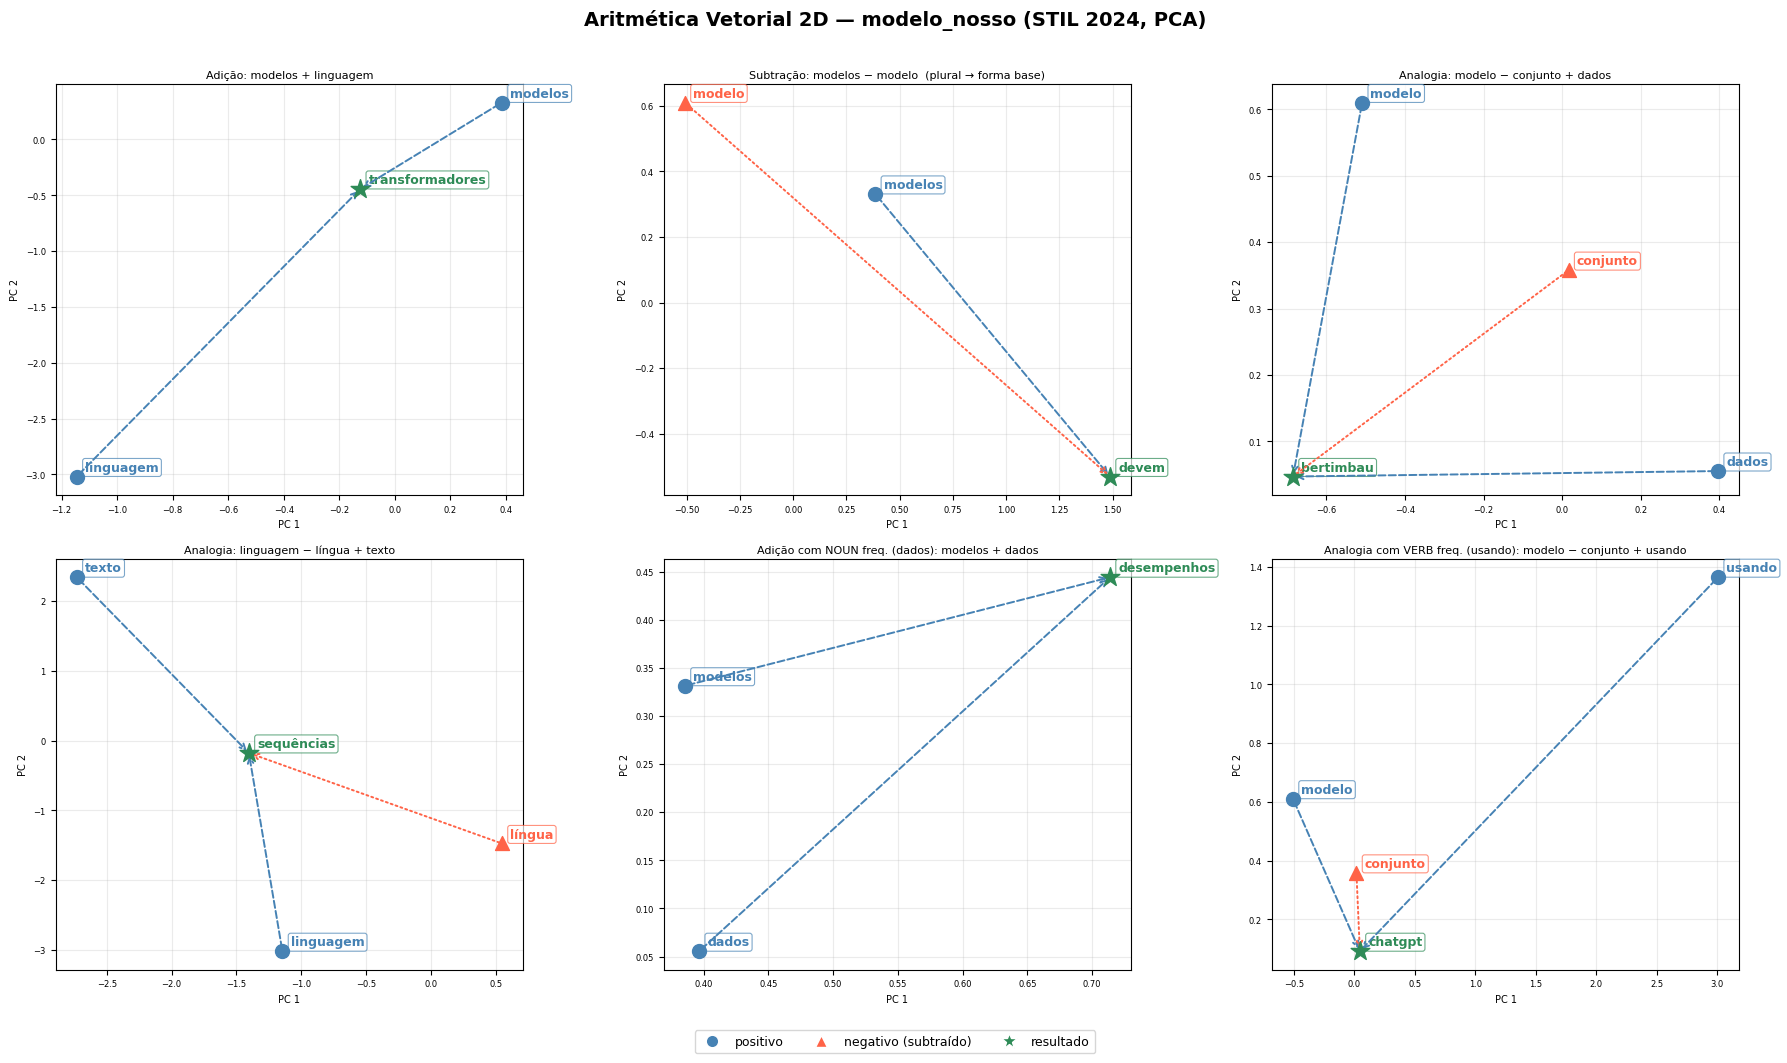

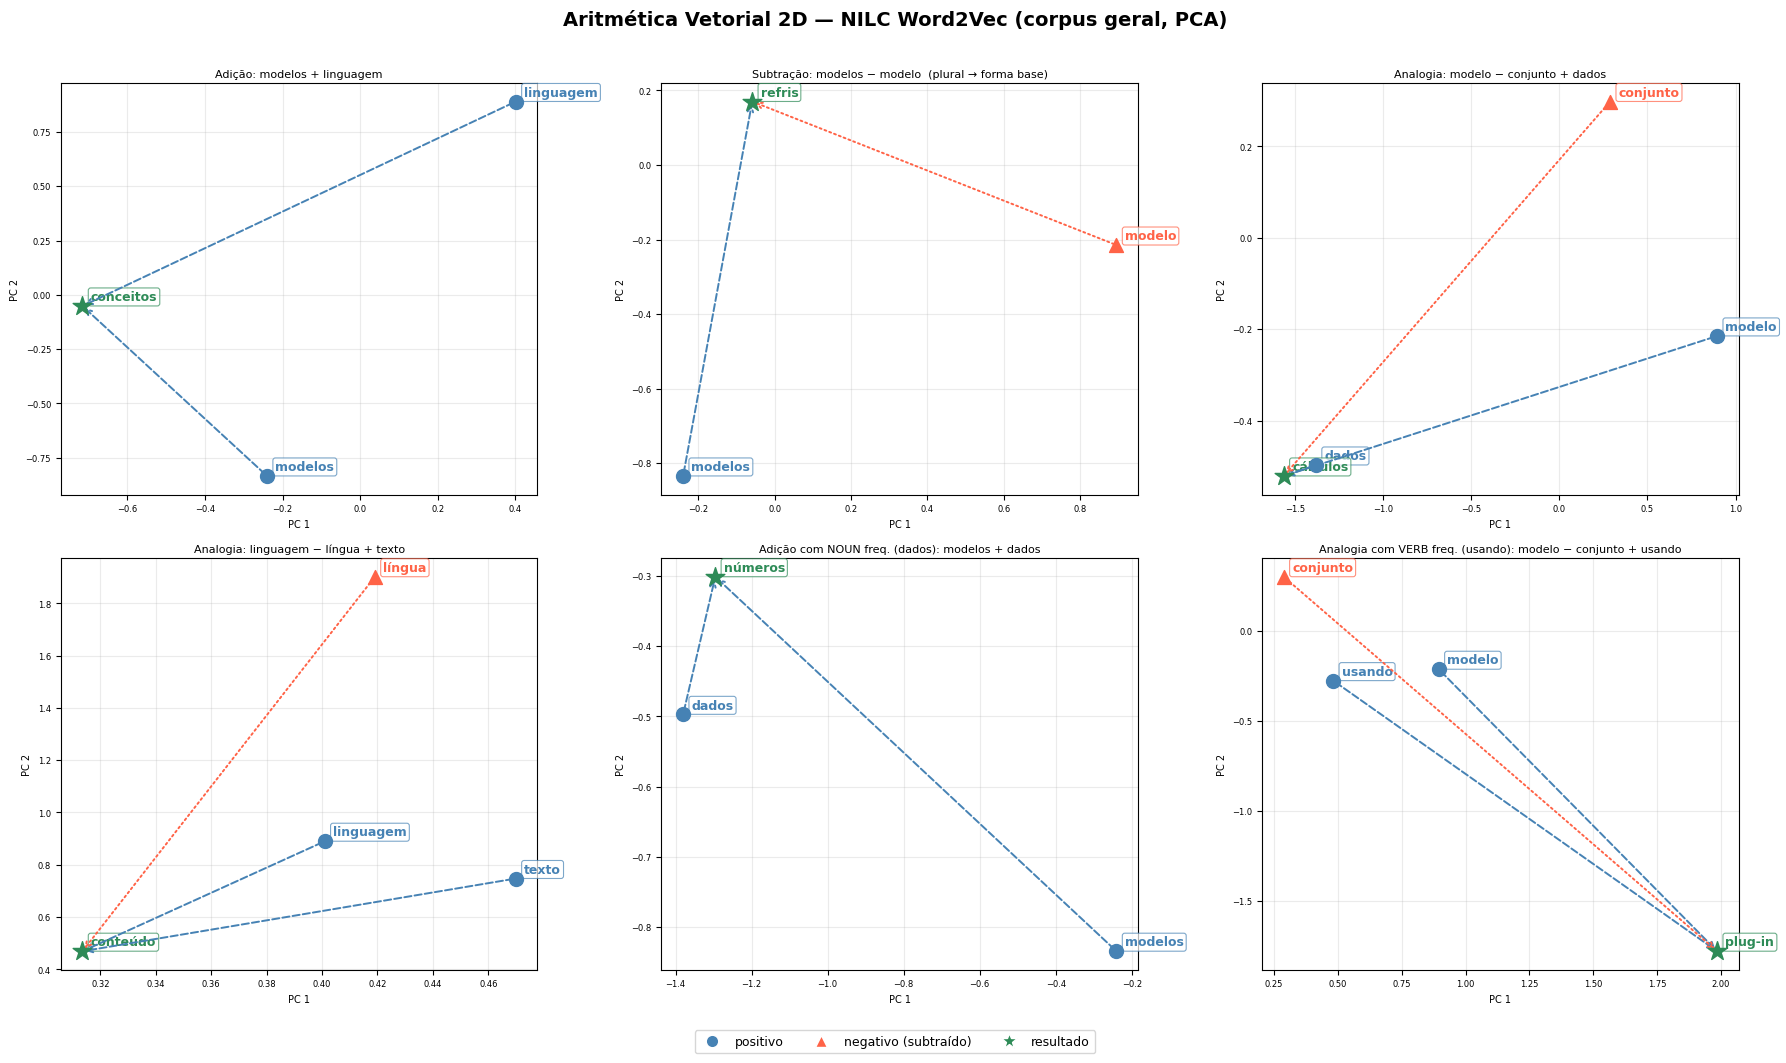

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_aritmetica_2d(wv, analogias, titulo, topn=1):
    """
    For each analogy, collect operand words + top result, project all to 2D via PCA,
    then draw labelled arrows showing the vector operation geometrically.
    """
    # ── gather all words that will appear across all operations ──────────────
    all_words = set()
    op_results = []   # (descricao, positivos, negativos, resultado_word)

    for descricao, positivos, negativos in analogias:
        pos_ok  = [w for w in positivos if w in wv]
        neg_ok  = [w for w in negativos if w in wv]
        if not pos_ok:
            op_results.append((descricao, pos_ok, neg_ok, None))
            continue
        try:
            top = wv.most_similar(positive=pos_ok, negative=neg_ok, topn=topn)
            result_word = top[0][0]
        except Exception:
            result_word = None
        all_words.update(pos_ok + neg_ok)
        if result_word:
            all_words.add(result_word)
        op_results.append((descricao, pos_ok, neg_ok, result_word))

    if len(all_words) < 3:
        print(f"{titulo}: palavras insuficientes para PCA.")
        return

    # ── PCA fit on ALL words so coordinates are consistent across subplots ──
    word_list = sorted(all_words)
    vecs      = np.array([wv[w] for w in word_list])
    coords2d  = PCA(n_components=2, random_state=42).fit_transform(vecs)
    pos_map   = {w: coords2d[i] for i, w in enumerate(word_list)}

    valid_ops = [(d, p, n, r) for d, p, n, r in op_results if p and r]
    if not valid_ops:
        print(f"{titulo}: nenhuma operação válida para plotar.")
        return

    ncols = 3
    nrows = (len(valid_ops) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)  # flatten for easy indexing
    fig.suptitle(titulo, fontsize=14, fontweight="bold", y=1.01)

    COLORS = {"positive": "steelblue", "negative": "tomato", "result": "seagreen"}

    for ax, (descricao, positivos, negativos, result_word) in zip(axes, valid_ops):
        involved = {w: "positive" for w in positivos}
        involved.update({w: "negative" for w in negativos})
        involved[result_word] = "result"

        # ── draw origin-centred arrows for each operand ──────────────────────
        # Use the centroid of operands as a common origin for readability
        pts = np.array([pos_map[w] for w in list(positivos) + list(negativos) + [result_word]])
        cx, cy = pts.mean(axis=0)

        for w, role in involved.items():
            if w not in pos_map:
                continue
            x, y   = pos_map[w]
            color   = COLORS[role]
            marker  = "*" if role == "result" else ("^" if role == "negative" else "o")
            size    = 200 if role == "result" else 100
            ax.scatter(x, y, c=color, s=size, marker=marker, zorder=4)
            ax.annotate(
                w, (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=9, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec=color, lw=0.8),
            )

        # ── draw dashed arrows: positive words → result ──────────────────────
        rx, ry = pos_map[result_word]
        for w in positivos:
            if w in pos_map:
                wx, wy = pos_map[w]
                ax.annotate("", xy=(rx, ry), xytext=(wx, wy),
                            arrowprops=dict(arrowstyle="->", color="steelblue",
                                            lw=1.4, linestyle="dashed"))
        # ── draw solid arrows: negative words → result (subtraction) ─────────
        for w in negativos:
            if w in pos_map:
                wx, wy = pos_map[w]
                ax.annotate("", xy=(rx, ry), xytext=(wx, wy),
                            arrowprops=dict(arrowstyle="->", color="tomato",
                                            lw=1.4, linestyle="dotted"))

        # ── label expression ─────────────────────────────────────────────────
        expr = " + ".join(positivos)
        if negativos:
            expr += " − " + " − ".join(negativos)
        short_desc = descricao.split("\n")[0]
        ax.set_title(short_desc, fontsize=8, pad=4)
        ax.set_xlabel("PC 1", fontsize=7); ax.set_ylabel("PC 2", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.25)

    # Hide unused subplots
    for ax in axes[len(valid_ops):]:
        ax.set_visible(False)

    # ── legend ────────────────────────────────────────────────────────────────
    from matplotlib.lines import Line2D
    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=9,  label='positivo'),
        Line2D([0],[0], marker='^', color='w', markerfacecolor='tomato',    markersize=9,  label='negativo (subtraído)'),
        Line2D([0],[0], marker='*', color='w', markerfacecolor='seagreen',  markersize=12, label='resultado'),
    ]
    fig.legend(handles=legend_els, loc="lower center", ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, -0.04), frameon=True)
    plt.tight_layout()
    plt.show()

# ── Run for both models ───────────────────────────────────────────────────────
plot_aritmetica_2d(
    modelo_nosso.wv, analogias,
    "Aritmética Vetorial 2D — modelo_nosso (STIL 2024, PCA)"
)
plot_aritmetica_2d(
    kv_w2v, analogias,
    "Aritmética Vetorial 2D — NILC Word2Vec (corpus geral, PCA)"
)

### Síntese — AP4

1. **Vetores (Q1):** O NILC tem vetores mais estáveis (~1 bilhão de tokens de treino).
   O `modelo_nosso` possui 1.821 palavras (min\_count=5, ~87 mil tokens) — vetores mais ruidosos mas específicos do domínio NLP.

2. **Similaridade (Q2):** `modelo_nosso` retorna vizinhos do domínio NLP (nomes de modelos, tarefas, datasets).
   O NILC retorna vizinhos do português geral.

3. **Aritmética (Q3):** As analogias funcionam melhor no NILC. No `modelo_nosso` os resultados
   são menos previsíveis pelo corpus reduzido, mas ainda refletem o domínio NLP.

# BERTimbau para vetores, similaridade e classificação de estilo de escrita
Continuação do AP4 (que treinou um Word2Vec no corpus do STIL 2024). Aqui usamos o BERTimbau (neuralmind/bert-base-portuguese-cased).

Diferença-chave em relação ao Word2Vec: o BERT é contextual — a mesma palavra tem vetores diferentes em frases diferentes. Para responder "qual o vetor da palavra X" e "quais termos são mais similares a X", passamos as frases do corpus pelo BERT e tiramos a média dos embeddings contextuais de cada palavra. Isso transforma o BERT contextual em uma tabela palavra → vetor (estática), comparável ao Word2Vec.


In [ ]:
!pip install -q transformers datasets accelerate scikit-learn spacy
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 41.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import torch
warnings.filterwarnings("ignore")

random.seed(42); np.random.seed(42); torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

In [ ]:
import os

CAMINHO = "output_final.json"
if not os.path.exists(CAMINHO) and os.path.exists("/content/output_final.json"):
    CAMINHO = "/content/output_final.json"
assert os.path.exists(CAMINHO), "output_final.json nao encontrado - rode a extracao (Cell 8) antes."
print(f"{CAMINHO} ({os.path.getsize(CAMINHO) / 1e6:.2f} MB)")

from google.colab import files
files.download(CAMINHO)

output_final.json (4.42 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Etapa 0 — Carregar o corpus de uma pasta do Google Drive (pular a extração)

Para rodar a AP5 **sem re-executar** o scraping + download de PDFs + limpeza (Cells 2–10),
esta célula baixa o `output_final.json` de uma **pasta do Google Drive**, informando apenas o
**ID da pasta** (o trecho final da URL `https://drive.google.com/drive/folders/<ID>`), e
reconstrói as variáveis usadas pela AP5: `data_clean`, `nlp`, `all_tokens`, `all_pos`,
`PT_STOPWORDS`, `PALAVRAS_ALVO` e `ROTULOS`.

> Defina `DRIVE_FOLDER_ID` abaixo. A pasta precisa estar compartilhada como
> *"qualquer pessoa com o link"*. Se já executou o notebook inteiro nesta sessão, as variáveis
> já existem e a célula apenas reaproveita o que estiver em memória.

In [ ]:
# Etapa 0 - puxa o corpus de uma pasta do Google Drive pelo ID da pasta
!pip install -q gdown
import gdown, glob, os, json, spacy
from collections import Counter
from spacy.lang.pt.stop_words import STOP_WORDS as PT_STOPWORDS

DRIVE_FOLDER_ID = "1KwmpPhEJsBQJvi1p9rSGSAvpm8RROyOP"   # trecho final de .../drive/folders/<ID>
NOME_JSON       = "still_dataset_output.json"          # nome do arquivo do corpus na pasta
DEST            = "corpus_drive"

# Baixa todos os arquivos da pasta do Drive (apenas se ainda nao baixou)
if not os.path.isdir(DEST):
    gdown.download_folder(id=DRIVE_FOLDER_ID, output=DEST, quiet=False, use_cookies=False)

# Localiza o JSON do corpus dentro do que foi baixado
candidatos = glob.glob(os.path.join(DEST, "**", NOME_JSON), recursive=True) \
          or glob.glob(os.path.join(DEST, "**", "*.json"), recursive=True)
if not candidatos:
    raise FileNotFoundError(f"Nenhum JSON encontrado em '{DEST}'. Confira o ID/compartilhamento da pasta.")
CAMINHO_JSON = candidatos[0]
print("JSON do corpus:", CAMINHO_JSON)

# spaCy (PT) - carrega so se ainda nao estiver em memoria
try:
    nlp
except NameError:
    try:
        nlp = spacy.load("pt_core_news_sm")
    except OSError:
        from spacy.cli import download
        download("pt_core_news_sm")
        nlp = spacy.load("pt_core_news_sm")

# Corpus limpo
with open(CAMINHO_JSON, encoding="utf-8") as f:
    data_clean = json.load(f)
_textos = [a["artigo_completo"] for a in data_clean if a.get("artigo_completo")]
print(f"Artigos carregados: {len(data_clean)} | com texto: {len(_textos)}")

# all_tokens / all_pos (necessarios na Q2) - reconstroi se ausentes
if "all_tokens" not in globals() or not all_tokens:
    all_tokens, all_pos = [], []
    for doc in nlp.pipe(_textos, batch_size=4):
        for t in doc:
            if not t.is_space:
                all_tokens.append(t.text); all_pos.append(t.pos_)
    print(f"Tokens analisados: {len(all_tokens):,}")

# PALAVRAS_ALVO / ROTULOS - a) e b) fixos; c) e d) = subst./verbo mais frequentes do corpus
if "PALAVRAS_ALVO" not in globals():
    _pares = [(tok.lower(), pos) for tok, pos in zip(all_tokens, all_pos)
              if tok.isalpha() and tok.lower() not in PT_STOPWORDS and len(tok) > 2]
    SUBSTANTIVO_FREQ = Counter(t for t, p in _pares if p == "NOUN").most_common(1)[0][0]
    VERBO_FREQ       = Counter(t for t, p in _pares if p == "VERB").most_common(1)[0][0]
    PALAVRAS_ALVO = ["modelos", "linguagem", SUBSTANTIVO_FREQ, VERBO_FREQ]
    ROTULOS = ["a) modelos", "b) linguagem",
               f"c) NOUN mais freq.: '{SUBSTANTIVO_FREQ}'",
               f"d) VERB mais freq.: '{VERBO_FREQ}'"]
print("PALAVRAS_ALVO:", PALAVRAS_ALVO)

Retrieving folder contents


Processing file 1dTQtfrTxp1Wf-U3a3j6WF8uN_RGNhlfF bertimbau_stil2024_mlm.zip
Processing file 1XrcTUHT4r5cZEsD9yLqyDRK5mcArWO0- still_dataset_output.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1dTQtfrTxp1Wf-U3a3j6WF8uN_RGNhlfF
From (redirected): https://drive.google.com/uc?id=1dTQtfrTxp1Wf-U3a3j6WF8uN_RGNhlfF&confirm=t&uuid=0d9cdbbc-8b88-4de1-a499-344eeebb2423
To: /content/corpus_drive/bertimbau_stil2024_mlm.zip
100%|██████████| 405M/405M [00:08<00:00, 48.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XrcTUHT4r5cZEsD9yLqyDRK5mcArWO0-
To: /content/corpus_drive/still_dataset_output.json
100%|██████████| 4.42M/4.42M [00:00<00:00, 18.2MB/s]
Download completed


JSON do corpus: corpus_drive/still_dataset_output.json
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Artigos carregados: 30 | com texto: 30
Tokens analisados: 86,732
PALAVRAS_ALVO: ['modelos', 'linguagem', 'dados', 'usando']


In [ ]:
# Frases (como strings) extraidas do corpus limpo - base para o fine-tuning e as tarefas.
# (No AP4 a Cell 31 produziu listas de tokens; aqui precisamos do texto continuo.)
textos = [a["artigo_completo"] for a in data_clean if a.get("artigo_completo")]

frases_str = []
for doc in nlp.pipe(textos, batch_size=4):
    for sent in doc.sents:
        s = sent.text.strip()
        if 4 <= len(s.split()) <= 60:        # descarta fragmentos e frases gigantes
            frases_str.append(s)

print(f"Frases (strings) no corpus: {len(frases_str):,}")
print("Exemplo:", frases_str[0][:120], "...")

Frases (strings) no corpus: 3,388
Exemplo: Introdução
Sistemas de biometria de voz estão sendo amplamente utilizados nos mais diversos seto-
res, como indústria au ...


### Etapa 1 — Fine-tuning do BERTimbau em todo o corpus (MLM)

Adaptação de domínio: continuamos o pré-treino do BERTimbau na tarefa de **Masked Language
Modeling** usando *todas* as frases dos artigos. O `DataCollatorForLanguageModeling` mascara
~15% dos tokens e o modelo aprende a prevê-los, ajustando seus pesos ao vocabulário e ao
estilo do corpus de PLN.

Ao final, salvamos o modelo adaptado em `bertimbau_stil2024_mlm/` e recarregamos o **encoder
adaptado** (`bert_encoder`) — é ele que será usado nas Questões 1 e 2.

In [ ]:
from transformers import (AutoModelForMaskedLM, AutoModel, AutoTokenizer,
                          DataCollatorForLanguageModeling, TrainingArguments, Trainer)
from datasets import Dataset
import torch

# Garante tokenizer/DEVICE caso a celula de setup nao tenha sido executada nesta sessao
BERTIMBAU = globals().get("BERTIMBAU", "neuralmind/bert-base-portuguese-cased")
if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if "tokenizer_bert" not in globals():
    tokenizer_bert = AutoTokenizer.from_pretrained(BERTIMBAU)

MODELO_ADAPTADO = "bertimbau_stil2024_mlm"

# Dataset MLM: todas as frases do corpus, tokenizadas
ds_mlm = Dataset.from_dict({"text": frases_str})
ds_mlm = ds_mlm.map(
    lambda b: tokenizer_bert(b["text"], truncation=True, max_length=128),
    batched=True, remove_columns=["text"])

mlm_model = AutoModelForMaskedLM.from_pretrained(BERTIMBAU)
collator  = DataCollatorForLanguageModeling(tokenizer_bert, mlm=True, mlm_probability=0.15)

args_mlm = TrainingArguments(
    output_dir=MODELO_ADAPTADO, num_train_epochs=3,
    per_device_train_batch_size=16, learning_rate=5e-5,
    logging_steps=100, report_to="none", seed=42, save_strategy="no")

import inspect
_tk = dict(model=mlm_model, args=args_mlm, train_dataset=ds_mlm, data_collator=collator)
# 'tokenizer' virou 'processing_class' no transformers recente
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    _tk["processing_class"] = tokenizer_bert
else:
    _tk["tokenizer"] = tokenizer_bert
trainer_mlm = Trainer(**_tk)
trainer_mlm.train()
trainer_mlm.save_model(MODELO_ADAPTADO)
tokenizer_bert.save_pretrained(MODELO_ADAPTADO)

# Recarrega o ENCODER adaptado (sem cabeca de MLM) para extrair embeddings nas Q1/Q2
bert_encoder = AutoModel.from_pretrained(MODELO_ADAPTADO).to(DEVICE).eval()
print(f"\nBERTimbau adaptado ao dominio STIL 2024 salvo em '{MODELO_ADAPTADO}/'")
print(f"Encoder: {bert_encoder.config.hidden_size}d, "
      f"{bert_encoder.config.num_hidden_layers} camadas")

Map:   0%|          | 0/3388 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Step,Training Loss
100,2.322700
200,2.144751
300,1.910694
400,1.943332
500,1.823305
600,1.715480


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bertimbau_stil2024_mlm
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTimbau adaptado ao dominio STIL 2024 salvo em 'bertimbau_stil2024_mlm/'
Encoder: 768d, 12 camadas


#### Salvar / baixar o modelo adaptado

O treino MLM já grava o modelo em `bertimbau_stil2024_mlm/`. As células abaixo **compactam**
o diretório para download e oferecem a opção de **recarregar** um modelo já treinado — assim
você pode pular a Etapa 1 em execuções futuras.

In [ ]:
# Compacta o modelo adaptado para download
import shutil, os

ZIP_BASE = MODELO_ADAPTADO            # "bertimbau_stil2024_mlm"
shutil.make_archive(ZIP_BASE, "zip", MODELO_ADAPTADO)
print(f"Modelo salvo em '{MODELO_ADAPTADO}/' e compactado em '{ZIP_BASE}.zip' "
      f"({os.path.getsize(ZIP_BASE + '.zip') / 1e6:.1f} MB)")

# Em Colab, descomente para baixar o .zip:
from google.colab import files
files.download(f"{ZIP_BASE}.zip")

Modelo salvo em 'bertimbau_stil2024_mlm/' e compactado em 'bertimbau_stil2024_mlm.zip' (404.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# (Opcional) Recarregar o modelo JA treinado de uma pasta do Google Drive e PULAR a Etapa 1.
# Util quando o modelo adaptado ja foi salvo no Drive em uma execucao anterior.
!pip install -q gdown
import os, glob, shutil, gdown
from transformers import AutoModel, AutoTokenizer
import torch

MODEL_DRIVE_FOLDER_ID = "1KwmpPhEJsBQJvi1p9rSGSAvpm8RROyOP"   # .../drive/folders/<ID>
MODELO_ADAPTADO       = "bertimbau_stil2024_mlm"
BERTIMBAU = globals().get("BERTIMBAU", "neuralmind/bert-base-portuguese-cased")
if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Baixa a pasta do modelo do Drive (so se ainda nao houver o modelo local)
if not os.path.isdir(MODELO_ADAPTADO):
    gdown.download_folder(id=MODEL_DRIVE_FOLDER_ID, output="modelo_drive",
                          quiet=False, use_cookies=False)
    # Caso a pasta contenha um .zip, descompacta; senao, localiza a pasta com config.json
    zips = glob.glob("modelo_drive/**/*.zip", recursive=True)
    if zips:
        shutil.unpack_archive(zips[0], MODELO_ADAPTADO)
    else:
        cfgs = glob.glob("modelo_drive/**/config.json", recursive=True)
        MODELO_ADAPTADO = os.path.dirname(cfgs[0]) if cfgs else "modelo_drive"

tokenizer_bert = AutoTokenizer.from_pretrained(MODELO_ADAPTADO)
bert_encoder   = AutoModel.from_pretrained(MODELO_ADAPTADO).to(DEVICE).eval()
print(f"Modelo adaptado recarregado de '{MODELO_ADAPTADO}' - Etapa 1 pode ser pulada.")

### Questão 1 — Vetores gerados para as palavras-alvo (BERTimbau adaptado)

Palavras: **a) modelos**, **b) linguagem**, **c)** substantivo mais frequente do corpus,
**d)** verbo mais frequente do corpus (os mesmos `PALAVRAS_ALVO` do AP4).

O BERT gera **embeddings contextuais** (um vetor por ocorrência) e usa **WordPiece**
(`linguagem` → `lingu` + `##agem`). Para cada ocorrência recuperamos os vetores dos
sub-tokens da palavra (via `offset_mapping`), tiramos a média deles e, ao final, agregamos
por média todas as ocorrências → **um vetor contextual agregado de 768 dimensões**,
agora produzido pelo encoder **já adaptado** ao corpus.

In [ ]:
@torch.no_grad()
def embedding_contextual(palavra, frases, max_ocorr=60, max_len=128):
    """Media dos vetores (ultimo hidden state) da `palavra` em todas as suas ocorrencias."""
    pat = re.compile(rf"\b{re.escape(palavra.lower())}\b")
    vetores = []
    for s in frases:
        if not pat.search(s.lower()):
            continue
        enc = tokenizer_bert(s, return_offsets_mapping=True, return_tensors="pt",
                             truncation=True, max_length=max_len)
        offsets = enc.pop("offset_mapping")[0].tolist()
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        hidden = bert_encoder(**enc).last_hidden_state[0]      # (seq, 768)
        for m in pat.finditer(s.lower()):
            ini, fim = m.start(), m.end()
            idxs = [i for i, (a, b) in enumerate(offsets) if a < fim and b > ini and a != b]
            if idxs:
                vetores.append(hidden[idxs].mean(0).cpu().numpy())
        if len(vetores) >= max_ocorr:
            break
    if not vetores:
        return None, 0
    return np.mean(vetores, axis=0), len(vetores)

print("=" * 70)
print("QUESTAO 1 - Vetores contextuais agregados (BERTimbau adaptado, 768d)")
print("=" * 70)

emb_alvo = {}
for palavra, rotulo in zip(PALAVRAS_ALVO, ROTULOS):
    vec, n = embedding_contextual(palavra, frases_str)
    print(f"\n--- {rotulo} ---")
    if vec is None:
        print(f"  '{palavra}' nao encontrada no corpus.")
        continue
    emb_alvo[palavra] = vec
    print(f"  Ocorrencias agregadas: {n}")
    print(f"  Dims[0:10]: {np.round(vec[:10], 4)}")
    print(f"  Norma L2:   {np.linalg.norm(vec):.4f}")

QUESTAO 1 - Vetores contextuais agregados (BERTimbau adaptado, 768d)

--- a) modelos ---
  Ocorrencias agregadas: 60
  Dims[0:10]: [ 0.1004 -0.0435  1.1108 -0.1274 -0.0168  0.3028 -0.0934 -0.1298  0.3335
 -0.3923]
  Norma L2:   10.3344

--- b) linguagem ---
  Ocorrencias agregadas: 60
  Dims[0:10]: [-0.0236 -0.177   0.5752 -0.421   0.4587 -0.3791 -0.4459 -0.104  -0.6839
  0.3782]
  Norma L2:   11.5899

--- c) NOUN mais freq.: 'dados' ---
  Ocorrencias agregadas: 60
  Dims[0:10]: [-0.1207 -0.1889  1.3588 -0.3322  0.3083  0.4785 -0.0389 -0.112  -0.2635
 -0.5977]
  Norma L2:   11.3929

--- d) VERB mais freq.: 'usando' ---
  Ocorrencias agregadas: 60
  Dims[0:10]: [ 0.0933 -0.265   1.6065 -0.4614  0.1998 -0.4486  0.3136 -0.345   0.6486
 -1.4084]
  Norma L2:   11.3796


### Questão 2 — Termos mais similares (top-10 por similaridade de cosseno)

Construímos um vocabulário com as palavras de conteúdo mais frequentes do corpus
(`NOUN`, `VERB`, `ADJ`, `PROPN`), calculamos o embedding contextual agregado de cada uma
**com o modelo adaptado** (mesmo método da Q1) e medimos a **similaridade de cosseno** com
cada palavra-alvo.

> O cálculo roda um forward do BERT por ocorrência — em CPU pode levar alguns minutos.
> Use uma GPU (Runtime → Alterar tipo de ambiente de execução → GPU) para acelerar.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Vocabulario-alvo: palavras de conteudo mais frequentes (reusa all_tokens/all_pos do AP4)
cont = Counter(
    tok.lower() for tok, pos in zip(all_tokens, all_pos)
    if tok.isalpha() and len(tok) > 3 and tok.lower() not in PT_STOPWORDS
    and pos in {"NOUN", "VERB", "ADJ", "PROPN"}
)
# Sem teto de top-N: usa TODAS as palavras de conteudo do corpus.
# MIN_FREQ e apenas um filtro de qualidade (1 ocorrencia gera embedding ruidoso e custa caro).
# Use MIN_FREQ = 1 para nao filtrar absolutamente nada.
MIN_FREQ  = 2
MAX_OCORR = 15
vocab_sim = [w for w, f in cont.most_common() if f >= MIN_FREQ]
for p in PALAVRAS_ALVO:                       # garante que as palavras-alvo estao no conjunto
    if p not in vocab_sim:
        vocab_sim.append(p)

print(f"Calculando embeddings contextuais de {len(vocab_sim)} palavras (modelo adaptado)...")
print("  (sem limite de vocabulario - pode levar varios minutos; use GPU)")
emb_vocab = {}
for w in tqdm(vocab_sim):
    v, _ = embedding_contextual(w, frases_str, max_ocorr=MAX_OCORR)
    if v is not None:
        emb_vocab[w] = v

palavras_v = list(emb_vocab.keys())
M = np.vstack([emb_vocab[w] for w in palavras_v])

def similares_bert(palavra, topn=10):
    if palavra not in emb_vocab:
        print(f"    '{palavra}' sem embedding (nao ocorre no corpus).")
        return
    sims  = cosine_similarity(emb_vocab[palavra].reshape(1, -1), M)[0]
    ordem = np.argsort(-sims)
    mostrados = 0
    for i in ordem:
        if palavras_v[i] == palavra:
            continue
        print(f"    {palavras_v[i]:25} {sims[i]:.4f}")
        mostrados += 1
        if mostrados >= topn:
            break

print("\n" + "=" * 70)
print("QUESTAO 2 - Termos mais similares (top-10, cosseno sobre BERTimbau adaptado)")
print("=" * 70)
for palavra, rotulo in zip(PALAVRAS_ALVO, ROTULOS):
    print(f"\n--- {rotulo} ---")
    similares_bert(palavra)

Calculando embeddings contextuais de 3372 palavras (modelo adaptado)...
  (sem limite de vocabulario - pode levar varios minutos; use GPU)


  0%|          | 0/3372 [00:00<?, ?it/s]


QUESTAO 2 - Termos mais similares (top-10, cosseno sobre BERTimbau adaptado)

--- a) modelos ---
    modelo                    0.8166
    métodos                   0.6948
    algoritmos                0.6845
    cenários                  0.6786
    ensaios                   0.6742
    gráficos                  0.6626
    experimentos              0.6591
    sistemas                  0.6522
    módulos                   0.6499
    testes                    0.6476

--- b) linguagem ---
    língua                    0.7754
    linguagens                0.7562
    linguística               0.7038
    lingüística               0.6765
    línguas                   0.6637
    language                  0.6623
    linguístico               0.6610
    gramatical                0.6570
    sintaxe                   0.6568
    linguísticos              0.6458

--- c) NOUN mais freq.: 'dados' ---
    informação                0.6145
    informações               0.5867
    pesquisa                 

### Questão 3 — Classificação de estilo de escrita (zero-shot por descrição)

**Tarefa proposta:** classificar cada frase do corpus em **Acadêmico / Narrativo / Descritivo**
usando como entrada as **próprias descrições dos estilos** dadas no enunciado — sem rótulos
de treino.

**Como funciona (zero-shot por protótipos):**
1. Codificamos cada **descrição de estilo** com o BERTimbau adaptado (mean pooling) →
   um vetor-protótipo de 768d por categoria.
2. Codificamos cada frase do corpus da mesma forma.
3. A **última camada** é uma camada linear sem viés cujos **pesos são os protótipos das
   descrições** (`W = [v_acad; v_narr; v_descr]`). Para uma frase com embedding `h`:
   `logits = W · h` (similaridade com cada descrição) → `softmax` → distribuição sobre as
   3 categorias. O `argmax` é o estilo previsto.

Ou seja, o modelo mapeia a predição **entre as categorias propostas**, e essas categorias são
definidas pelo texto das descrições — não por exemplos rotulados.

In [ ]:
# 1) Embedding de frase = mean pooling do ultimo hidden state (modelo adaptado)
from sklearn.preprocessing import normalize

@torch.no_grad()
def embed_frases(frases, batch_size=32, max_len=128):
    out = []
    for i in tqdm(range(0, len(frases), batch_size)):
        lote = frases[i:i + batch_size]
        enc  = tokenizer_bert(lote, return_tensors="pt", padding=True,
                              truncation=True, max_length=max_len).to(DEVICE)
        hidden = bert_encoder(**enc).last_hidden_state           # (B, L, 768)
        mask   = enc["attention_mask"].unsqueeze(-1).float()     # (B, L, 1)
        mean   = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        out.append(mean.cpu().numpy())
    return np.vstack(out)

In [ ]:
# 2) Descricoes dos estilos (do enunciado) -> prototipos -> ULTIMA CAMADA
import torch.nn as nn

DESCRICOES_ESTILO = {
    "Academico":  ("Uso frequente da terceira pessoa do singular ou da voz passiva, como "
                   "'observou-se que'. Evita adjetivos, jargoes, girias e superlativos "
                   "desnecessarios."),
    "Narrativo":  ("Escrita mais fluida, reflexiva e por vezes em primeira pessoa do plural, "
                   "como 'analisamos os dados', aproximando-se de um ensaio academico."),
    "Descritivo": ("Rigor extremo, frases curtas, objetividade matematica ou estatistica e "
                   "ordenacao cronologica ou logica dos fatos."),
}
ESTILOS = list(DESCRICOES_ESTILO.keys())

# Prototipo de cada estilo = embedding (L2-normalizado) da sua descricao
proto = normalize(embed_frases(list(DESCRICOES_ESTILO.values())))   # (3, 768)

# Ultima camada: Linear(768 -> 3) SEM vies, com pesos = prototipos das descricoes.
# logits[c] = <h_normalizado, prototipo_c> = similaridade de cosseno com a descricao c.
camada_estilo = nn.Linear(bert_encoder.config.hidden_size, len(ESTILOS), bias=False)
camada_estilo.weight.data = torch.tensor(proto, dtype=torch.float32)
camada_estilo.eval()

def classificar_estilo(frases, temperatura=10.0):
    """Mapeia cada frase para uma das categorias via a camada de prototipos + softmax."""
    h = torch.tensor(normalize(embed_frases(frases)), dtype=torch.float32)
    with torch.no_grad():
        logits = camada_estilo(h) * temperatura          # escala o cosseno antes do softmax
        probs  = torch.softmax(logits, dim=1).numpy()
    return probs.argmax(1), probs

print("Prototipos de estilo:", proto.shape, "| categorias:", ESTILOS)

  0%|          | 0/1 [00:00<?, ?it/s]

Prototipos de estilo: (3, 768) | categorias: ['Academico', 'Narrativo', 'Descritivo']


In [ ]:
# 3) Classifica o corpus e inspeciona o resultado
import random
random.seed(42)
amostra = frases_str if len(frases_str) <= 4000 else random.sample(frases_str, 4000)

pred, probs = classificar_estilo(amostra)
amostra_arr = np.array(amostra, dtype=object)

print("=" * 70)
print("Distribuicao dos estilos previstos no corpus")
print("=" * 70)
for c, est in enumerate(ESTILOS):
    print(f"  {est:11}: {(pred == c).sum():5d} frases  ({(pred == c).mean():.1%})")

print("\nFrases mais representativas de cada estilo (maior probabilidade):")
for c, est in enumerate(ESTILOS):
    idx = np.where(pred == c)[0]
    top = idx[np.argsort(-probs[idx, c])[:3]]
    print(f"\n--- {est} ---")
    for i in top:
        print(f"  ({probs[i, c]:.2f}) {amostra_arr[i]}")

  0%|          | 0/106 [00:00<?, ?it/s]

Distribuicao dos estilos previstos no corpus
  Academico  :   138 frases  (4.1%)
  Narrativo  :  3243 frases  (95.7%)
  Descritivo :     7 frases  (0.2%)

Frases mais representativas de cada estilo (maior probabilidade):

--- Academico ---
  (0.67) Inclusão dos lemas de preposições, conjunções coordenativas e conjunções subordinadas no rótulo das relações q
  (0.66) Caso necessário, criação de frames provisórios para verbos novos ou sentidos no-
vos de formas verbais já pres
  (0.64) Na propagação de sujeitos omitidos de verbos na forma
infinitiva, explicitamos argumentos apenas se estes foss

--- Narrativo ---
  (0.70) Esta parte da nossa abordagem é inspirada no trabalho de .
  (0.70) Por conta disso, escolheu-se neste trabalho não ape-
nas realizar uma análise mais restrita sobre a concordânc
  (0.69) Até onde sabemos, esta é a primeira avaliação da anotação EUD para esta linguagem.

--- Descritivo ---
  (0.41) Modelo Macro F1 Precisão
  (0.39) As métricas de avaliação incluem Acurá

In [ ]:
# 4) Classificacao de frases novas (uma por estilo esperado)
exemplos = [
    "Observou-se que o modelo proposto apresentou desempenho superior ao baseline.",
    "Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.",
    "A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.",
]

pred, probs = classificar_estilo(exemplos)
print("=" * 70)
print("Classificacao zero-shot de frases novas")
print("=" * 70)
for s, p, pr in zip(exemplos, pred, probs):
    print(f"\n[{ESTILOS[p]:11}] {s}")
    print("   " + "   ".join(f"{e}: {v:.2f}" for e, v in zip(ESTILOS, pr)))

  0%|          | 0/1 [00:00<?, ?it/s]

Classificacao zero-shot de frases novas

[Narrativo  ] Observou-se que o modelo proposto apresentou desempenho superior ao baseline.
   Academico: 0.23   Narrativo: 0.59   Descritivo: 0.18

[Narrativo  ] Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.
   Academico: 0.17   Narrativo: 0.44   Descritivo: 0.39

[Descritivo ] A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.
   Academico: 0.23   Narrativo: 0.34   Descritivo: 0.42


---
## ap6 — LLM finetunado com artigos (Qwen2.5-1.5B · QLoRA + PEFT)

Continuação do AP5 (que adaptou o BERTimbau ao corpus do STIL 2024). Aqui treinamos um **LLM generativo** — o **Qwen2.5-1.5B-Instruct** (família Qwen, ~1.5B parâmetros) — para a **mesma tarefa de classificação de estilo de escrita** (Acadêmico / Narrativo / Descritivo).

**Diferença-chave em relação ao AP5:** o BERTimbau classificava por *similaridade de embeddings* (encoder). Aqui o estilo é previsto por **geração condicionada**: dado o texto da frase, o LLM gera o rótulo. O ajuste usa **QLoRA** — o modelo base é carregado em **4 bits** (NF4) e apenas adaptadores **LoRA** (via PEFT) são treinados, cabendo numa GPU T4.

**Pipeline:**
1. **Rótulos fracos** — derivamos pares `(frase → estilo)` do corpus reaproveitando o classificador zero-shot do AP5 como *professor* (fallback heurístico se ele não estiver em memória).
2. **Fine-tuning QLoRA/PEFT** — adaptadores LoRA sobre o Qwen 4-bit (SFT supervisionado com TRL).
3. **Classificação** — pontuamos a verossimilhança de cada rótulo e aplicamos `softmax`, reproduzindo a distribuição do corpus e as 3 frases-teste do AP5.


### Etapa 0 — Instalação e dataset de fine-tuning (rótulos fracos do corpus)

Reaproveitamos `frases_str` (corpus limpo, da Etapa 0 do AP5) e geramos os rótulos com o classificador `classificar_estilo` do AP5 (zero-shot por protótipos do BERTimbau). Se ele não estiver na memória, caímos numa heurística simples baseada nas próprias descrições dos estilos. O resultado é um dataset no formato de chat do Qwen (`system` + `user` + `assistant` = rótulo).


# Etapa 0 - dependencias do QLoRA/PEFT (rodar uma vez)


In [ ]:
!pip install -q -U transformers peft bitsandbytes trl accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 178.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 65.9 MB/s eta 0:00:00


In [ ]:
# Constroi o dataset (frase -> estilo) com rotulos fracos e formato de chat do Qwen.
import random
from collections import Counter
from datasets import Dataset

random.seed(42)

# Estilos e descricoes (4 categorias; reaproveita do AP5 se ja estiverem em memoria)
if "DESCRICOES_ESTILO" not in globals():
    DESCRICOES_ESTILO = {
        "Academico":  ("Uso frequente da terceira pessoa do singular ou da voz passiva, como "
                       "'observou-se que'. Evita adjetivos, jargoes, girias e superlativos desnecessarios."),
        "Narrativo":  ("Escrita mais fluida, reflexiva e por vezes em primeira pessoa do plural, "
                       "como 'analisamos os dados', aproximando-se de um ensaio academico."),
        "Descritivo": ("Rigor extremo, frases curtas, objetividade matematica ou estatistica e "
                       "ordenacao cronologica ou logica dos fatos."),
        "IA":         ("Texto tipico gerado por IA: estrutura muito uniforme e previsivel, uso "
                       "frequente de conectivos de transicao (alem disso, ademais, por outro "
                       "lado, em suma), tom neutro e polido, linguagem cautelosa com hedging "
                       "(pode, geralmente, tende a) e fechamento com sintese ou recapitulacao."),
    }
    ESTILOS = list(DESCRICOES_ESTILO.keys())

# Prompt de sistema: a tarefa + as descricoes dos estilos
SYSTEM_ESTILO = (
    "Voce e um classificador de estilo de escrita academica. "
    "Classifique a frase em exatamente UMA categoria, respondendo apenas com o rotulo "
    f"({', '.join(DESCRICOES_ESTILO)}).\n"
    + "\n".join(f"- {e}: {d}" for e, d in DESCRICOES_ESTILO.items())
)

# Rotulos fracos: usa o classificador do AP5 (professor) se disponivel; senao, heuristica.
def _rotular_heuristico(s):
    t = s.lower()
    ia_marks = ("alem disso", "ademais", "por outro lado", "em suma", "vale ressaltar",
                "de modo geral", "tende a", "e importante ressaltar", "em conclusao")
    if sum(m in t for m in ia_marks) >= 2:
        return "IA"
    if any(p in t for p in ("analisamos", "observamos", "investigamos", "propomos",
                            "consideramos", "nossa", "nosso")):
        return "Narrativo"
    if sum(c.isdigit() for c in s) >= 2 and len(s.split()) <= 14:
        return "Descritivo"
    return "Academico"

# Amostra do corpus para gerar os pares (LLM e mais lento que o BERT; mantemos um subconjunto)
base = frases_str if len(frases_str) <= 3000 else random.sample(frases_str, 3000)

if "classificar_estilo" in globals():
    pred_prof, _ = classificar_estilo(base)          # professor: BERTimbau zero-shot do AP5
    rotulos = [ESTILOS[p] for p in pred_prof]
    fonte = "AP5 (BERTimbau zero-shot)"
else:
    rotulos = [_rotular_heuristico(s) for s in base]
    fonte = "heuristica"

pares = list(zip(base, rotulos))
print(f"Rotulos fracos via {fonte} | pares: {len(pares)}")
print("Distribuicao:", dict(Counter(rotulos)))

# Formato de chat do Qwen: system + user(frase) + assistant(rotulo)
def _para_mensagens(frase, rotulo):
    return [
        {"role": "system", "content": SYSTEM_ESTILO},
        {"role": "user", "content": f"Frase: {frase}\nEstilo:"},
        {"role": "assistant", "content": rotulo},
    ]

dados = [{"messages": _para_mensagens(f, r)} for f, r in pares]
random.shuffle(dados)
n_val = max(1, int(0.1 * len(dados)))
ds_train = Dataset.from_list(dados[n_val:])
ds_val   = Dataset.from_list(dados[:n_val])
print(f"treino: {len(ds_train)} | validacao: {len(ds_val)}")

Rotulos fracos via heuristica | pares: 3000
Distribuicao: {'Narrativo': 167, 'Academico': 2594, 'Descritivo': 239}
treino: 2700 | validacao: 300


### Etapa 1 — Fine-tuning QLoRA + PEFT no Qwen (4-bit)

Carregamos o Qwen2.5-1.5B-Instruct quantizado em **4 bits (NF4)** com `bitsandbytes`, preparamos para treino com `prepare_model_for_kbit_training` e injetamos adaptadores **LoRA** (PEFT) nas projeções de atenção e MLP. Só os adaptadores são treinados — o resto fica congelado e quantizado. O `SFTTrainer` (TRL) aplica o template de chat e treina por verossimilhança.

> API conforme `transformers`/`trl`/`peft` recentes (`SFTConfig.max_seq_length`, `processing_class`).

In [ ]:
# Etapa 1 - QLoRA: Qwen 4-bit + adaptadores LoRA (PEFT) treinados com SFT (TRL)
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# Nao existe "Qwen 3.5"; o 1.5B-instruct mais proximo e o Qwen2.5-1.5B-Instruct.
MODELO_BASE = "Qwen/Qwen2.5-1.5B-Instruct"
SAIDA_LORA  = "qwen-estilo-lora"

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tok = AutoTokenizer.from_pretrained(MODELO_BASE)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODELO_BASE, quantization_config=bnb, device_map="auto", torch_dtype=torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

cfg = SFTConfig(
    output_dir=SAIDA_LORA,
    num_train_epochs=2,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    bf16=True,
    optim="paged_adamw_8bit",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=cfg,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    peft_config=lora,
    processing_class=tok,
)
trainer.train()
trainer.save_model(SAIDA_LORA)
tok.save_pretrained(SAIDA_LORA)
print("Adaptadores LoRA salvos em:", SAIDA_LORA)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_1861/1283101425.py:33: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  cfg = SFTConfig(


Tokenizing train dataset:   0%|          | 0/2700 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,0.318127,0.300247,0.309438,0.939946,880909.000000
2,0.290171,0.293139,0.290575,0.940645,1761818.000000


Adaptadores LoRA salvos em: qwen-estilo-lora


#### Salvar / recarregar o adaptador LoRA

`SAIDA_LORA` guarda só os adaptadores (poucos MB). Para inferência usamos o modelo já em memória. A célula abaixo mostra como **recarregar** o Qwen 4-bit + adaptador numa nova sessão (pular a Etapa 1).

In [ ]:
# (Opcional) Recarregar o Qwen 4-bit + adaptador LoRA e PULAR a Etapa 1.
RECARREGAR = False
if RECARREGAR:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from peft import PeftModel
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                             bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)
    tok = AutoTokenizer.from_pretrained(SAIDA_LORA)
    base_m = AutoModelForCausalLM.from_pretrained(MODELO_BASE, quantization_config=bnb, device_map="auto")
    model = PeftModel.from_pretrained(base_m, SAIDA_LORA)

# Usa o modelo treinado em memoria para inferencia
if "trainer" in globals():
    model = trainer.model
model.config.use_cache = True
model.eval()
print("Modelo pronto para inferencia.")

Modelo pronto para inferencia.


### Questão — Classificação de estilo de escrita (Qwen finetunado)

Classificamos por **verossimilhança condicionada**: para cada frase montamos o prompt (`system` + `Frase: ... Estilo:`) e medimos o log-prob que o modelo atribui a cada rótulo (`Academico` / `Narrativo` / `Descritivo`). O `softmax` desses scores dá a distribuição sobre as 3 categorias — o `argmax` é o estilo previsto. (Mesma saída `(pred, probs)` do AP5.)

In [ ]:
# Classificacao por verossimilhanca do rotulo gerado (retorna pred, probs como no AP5)
import numpy as np
import torch
from tqdm.auto import tqdm

DEV = next(model.parameters()).device

def _prompt_estilo(frase):
    msgs = [{"role": "system", "content": SYSTEM_ESTILO},
            {"role": "user", "content": f"Frase: {frase}\nEstilo:"}]
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

@torch.no_grad()
def _logprob_rotulo(prompt, rotulo):
    p = tok(prompt, return_tensors="pt").input_ids.to(DEV)
    r = tok(rotulo, add_special_tokens=False, return_tensors="pt").input_ids.to(DEV)
    seq = torch.cat([p, r], dim=1)
    logp = torch.log_softmax(model(seq).logits[0], dim=-1)     # (T, V)
    # logp na posicao i preve o token i+1; o rotulo comeca em len(p)
    pos = list(range(p.size(1) - 1, seq.size(1) - 1))
    alvo = seq[0, p.size(1):]
    return logp[pos].gather(1, alvo.unsqueeze(1)).sum().item()

def classificar_qwen(frases):
    """Mapeia cada frase para uma das 3 categorias via verossimilhanca do rotulo + softmax."""
    pred, probs = [], []
    for f in tqdm(frases):
        s = np.array([_logprob_rotulo(_prompt_estilo(f), e) for e in ESTILOS])
        p = np.exp(s - s.max()); p = p / p.sum()
        pred.append(int(p.argmax())); probs.append(p)
    return np.array(pred), np.vstack(probs)

print("classificar_qwen pronto | categorias:", ESTILOS)

classificar_qwen pronto | categorias: ['Academico', 'Narrativo', 'Descritivo', 'IA']


In [ ]:
# Classifica uma amostra do corpus e inspeciona o resultado
# (LLM e mais lento que o BERT -> amostra menor que a do AP5)
import random
random.seed(42)
amostra = frases_str if len(frases_str) <= 600 else random.sample(frases_str, 600)

pred, probs = classificar_qwen(amostra)
amostra_arr = np.array(amostra, dtype=object)

print("=" * 70)
print("Distribuicao dos estilos previstos (Qwen finetunado)")
print("=" * 70)
for c, est in enumerate(ESTILOS):
    print(f"  {est:11}: {(pred == c).sum():5d} frases  ({(pred == c).mean():.1%})")

print("\nFrases mais representativas de cada estilo (maior probabilidade):")
for c, est in enumerate(ESTILOS):
    idx = np.where(pred == c)[0]
    if len(idx) == 0:
        continue
    top = idx[np.argsort(-probs[idx, c])[:3]]
    print(f"\n--- {est} ---")
    for i in top:
        print(f"  ({probs[i, c]:.2f}) {amostra_arr[i]}")

  0%|          | 0/600 [00:00<?, ?it/s]

Distribuicao dos estilos previstos (Qwen finetunado)
  Academico  :   565 frases  (94.2%)
  Narrativo  :     0 frases  (0.0%)
  Descritivo :    35 frases  (5.8%)
  IA         :     0 frases  (0.0%)

Frases mais representativas de cada estilo (maior probabilidade):

--- Academico ---
  (1.00) Ataque de replay consiste na apresentação a um ASV da reprodução de um áudio
previamente gravado, com o objetivo de validar a fala do locutor como genuína.
  (1.00) O método unificado propõe um
framework coeso que simplifica a integração de técnicas de ajuste fino, garantindo con-
sistência e eficiência na adaptação dos modelos.
  (1.00) Automatic Speaker Verification Spoofing and Counterme-
asures Challenge (ASVspoof) promove, desde 2015, o desenvolvimento de métodos para

detecção de falsificação.

--- Descritivo ---
  (0.96) Teste
1.007
Contexto
168,92 (73,77)
Pergunta
10,48 (3,30)
  (0.96) 9B
0,354 (0,046)
0,690 (0,020)
0,383 (0,034)
0,717 (0,023)
  (0.95) Ajuste fino
0,340
0,491
0,513
0,253
0,

In [ ]:
# Classificacao de frases novas (uma por estilo esperado) - mesmas do AP5
exemplos = [
    "Observou-se que o modelo proposto apresentou desempenho superior ao baseline.",
    "Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.",
    "A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.",
    "Alem disso, e importante ressaltar que a abordagem proposta, de modo geral, tende a contribuir significativamente para a area, abrangendo diversos aspectos relevantes.",
]

pred, probs = classificar_qwen(exemplos)
print("=" * 70)
print("Classificacao com o Qwen finetunado (QLoRA)")
print("=" * 70)
for s, p, pr in zip(exemplos, pred, probs):
    print(f"\n[{ESTILOS[p]:11}] {s}")
    print("   " + "   ".join(f"{e}: {v:.2f}" for e, v in zip(ESTILOS, pr)))

  0%|          | 0/4 [00:00<?, ?it/s]

Classificacao com o Qwen finetunado (QLoRA)

[Academico  ] Observou-se que o modelo proposto apresentou desempenho superior ao baseline.
   Academico: 0.92   Narrativo: 0.06   Descritivo: 0.02   IA: 0.00

[Academico  ] Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.
   Academico: 0.82   Narrativo: 0.18   Descritivo: 0.00   IA: 0.00

[Academico  ] A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.
   Academico: 0.82   Narrativo: 0.01   Descritivo: 0.17   IA: 0.00

[Academico  ] Alem disso, e importante ressaltar que a abordagem proposta, de modo geral, tende a contribuir significativamente para a area, abrangendo diversos aspectos relevantes.
   Academico: 0.94   Narrativo: 0.06   Descritivo: 0.00   IA: 0.00


### Síntese — ap6

1. **Abordagem:** QLoRA (Qwen2.5-1.5B em 4 bits + adaptadores LoRA via PEFT) treinado por SFT nos pares `(frase → estilo)` rotulados fracamente pelo classificador do AP5.

2. **Classificação generativa vs. encoder (AP5):** o BERTimbau decidia por similaridade de embeddings; aqui o Qwen prevê o rótulo por verossimilhança de geração. Como os rótulos de treino vêm do próprio AP5, o ap6 é, na prática, uma **destilação** do professor BERTimbau para um LLM generativo — tende a concordar com ele e a generalizar para frases novas.

3. **Custo:** o 4-bit + LoRA cabe numa GPU T4; só os adaptadores (poucos MB) são treinados e salvos. A inferência por verossimilhança é mais lenta que o BERT, por isso a amostra do corpus é menor.

---
## ap7 — LLM adaptado ao domínio + classificação zero-shot (self-supervised)

In [ ]:
# Etapa 1 - fine-tuning de LM (proximo token) no corpus, com QLoRA (self-supervised)
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset as HFDataset

MODELO_BASE_CLF = MODELO_BASE if "MODELO_BASE" in globals() else "Qwen/Qwen2.5-1.5B-Instruct"

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

tok_lm = AutoTokenizer.from_pretrained(MODELO_BASE_CLF)
if tok_lm.pad_token is None:
    tok_lm.pad_token = tok_lm.eos_token

lm_model = AutoModelForCausalLM.from_pretrained(
    MODELO_BASE_CLF, quantization_config=bnb, device_map="auto", torch_dtype=torch.bfloat16)
lm_model.config.use_cache = False
lm_model = prepare_model_for_kbit_training(lm_model)

lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
                  target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj"])

# Texto puro do corpus -> objetivo de linguagem (sem rotulos)
ds_lm = HFDataset.from_dict({"text": [s + tok_lm.eos_token for s in frases_str]})

cfg_lm = SFTConfig(output_dir="qwen-corpus-lm", num_train_epochs=1,
                   per_device_train_batch_size=8, gradient_accumulation_steps=2,
                   learning_rate=2e-4, lr_scheduler_type="cosine", warmup_ratio=0.03,
                   logging_steps=25, bf16=True, optim="paged_adamw_8bit",
                   dataset_text_field="text", report_to="none")

trainer_lm = SFTTrainer(model=lm_model, args=cfg_lm, train_dataset=ds_lm,
                        peft_config=lora, processing_class=tok_lm)
trainer_lm.train()

lm_model = trainer_lm.model          # Qwen adaptado ao dominio (4-bit + LoRA)
lm_model.config.use_cache = True
lm_model.eval()
del trainer_lm
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("LM adaptado ao corpus (QLoRA).")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_1861/2058124818.py:30: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  cfg_lm = SFTConfig(output_dir="qwen-corpus-lm", num_train_epochs=1,


Adding EOS to train dataset:   0%|          | 0/3388 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3388 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
25,3.336554
50,2.753073
75,2.685594
100,2.536969
125,2.535193
150,2.494327
175,2.513134
200,2.470051


LM adaptado ao corpus (QLoRA).


In [ ]:
# Etapa 2 - o modelo usa as DESCRICOES p/ inferir a classe (zero-shot) -> (pred, probs)
import numpy as np
from tqdm.auto import tqdm

# Estilos e descricoes (reaproveita do AP5/ap6 se ja estiverem em memoria)
if "DESCRICOES_ESTILO" not in globals():
    DESCRICOES_ESTILO = {
        "Academico":  ("Uso frequente da terceira pessoa do singular ou da voz passiva, como "
                       "'observou-se que'. Evita adjetivos, jargoes, girias e superlativos desnecessarios."),
        "Narrativo":  ("Escrita mais fluida, reflexiva e por vezes em primeira pessoa do plural, "
                       "como 'analisamos os dados', aproximando-se de um ensaio academico."),
        "Descritivo": ("Rigor extremo, frases curtas, objetividade matematica ou estatistica e "
                       "ordenacao cronologica ou logica dos fatos."),
        "IA":         ("Texto tipico gerado por IA: estrutura uniforme e previsivel, conectivos de "
                       "transicao (alem disso, ademais, em suma), tom neutro e cautela com hedging "
                       "(pode, geralmente, tende a)."),
    }
    ESTILOS = list(DESCRICOES_ESTILO.keys())

SYS_LABEL = ("Voce e um classificador de estilo de escrita. Responda apenas com o rotulo "
             f"({', '.join(DESCRICOES_ESTILO)}).\n"
             + "\n".join(f"- {e}: {d}" for e, d in DESCRICOES_ESTILO.items()))

DEV = next(lm_model.parameters()).device


def _prompt(s):
    msgs = [{"role": "system", "content": SYS_LABEL},
            {"role": "user", "content": f"Frase: {s}\nEstilo:"}]
    return tok_lm.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def _logprob(prompt, rotulo):
    p = tok_lm(prompt, return_tensors="pt").input_ids.to(DEV)
    r = tok_lm(rotulo, add_special_tokens=False, return_tensors="pt").input_ids.to(DEV)
    seq = torch.cat([p, r], dim=1)
    logp = torch.log_softmax(lm_model(seq).logits[0], dim=-1)
    pos = list(range(p.size(1) - 1, seq.size(1) - 1))
    alvo = seq[0, p.size(1):]
    return logp[pos].gather(1, alvo.unsqueeze(1)).sum().item()


def classificar_auto(frases):
    """Zero-shot via descricoes: devolve (pred, probs), como classificar_estilo/classificar_qwen."""
    pred, probs = [], []
    for s in tqdm(frases, desc="classificando"):
        sc = np.array([_logprob(_prompt(s), e) for e in ESTILOS])
        p = np.exp(sc - sc.max()); p = p / p.sum()
        pred.append(int(p.argmax())); probs.append(p)
    return np.array(pred), np.vstack(probs)


print("classificar_auto pronto | categorias:", ESTILOS)

classificar_auto pronto | categorias: ['Academico', 'Narrativo', 'Descritivo', 'IA']


### Análise do corpus (mesma do AP5 e do ap6)

Distribuição dos estilos previstos no corpus, frases mais representativas de cada estilo (maior probabilidade) e classificação das mesmas frases-exemplo (uma por estilo).

In [ ]:
# Classifica uma amostra do corpus e inspeciona o resultado
# (LLM e mais lento -> amostra menor, como no ap6)
import random
random.seed(42)
amostra = frases_str if len(frases_str) <= 600 else random.sample(frases_str, 600)

pred, probs = classificar_auto(amostra)
amostra_arr = np.array(amostra, dtype=object)

print("=" * 70)
print("Distribuicao dos estilos previstos (ap7: LLM adaptado + zero-shot)")
print("=" * 70)
for c, est in enumerate(ESTILOS):
    print(f"  {est:11}: {(pred == c).sum():5d} frases  ({(pred == c).mean():.1%})")

print("\nFrases mais representativas de cada estilo (maior probabilidade):")
for c, est in enumerate(ESTILOS):
    idx = np.where(pred == c)[0]
    if len(idx) == 0:
        continue
    top = idx[np.argsort(-probs[idx, c])[:3]]
    print(f"\n--- {est} ---")
    for i in top:
        print(f"  ({probs[i, c]:.2f}) {amostra_arr[i]}")

classificando:   0%|          | 0/600 [00:00<?, ?it/s]

Distribuicao dos estilos previstos (ap7: LLM adaptado + zero-shot)
  Academico  :    75 frases  (12.5%)
  Narrativo  :   133 frases  (22.2%)
  Descritivo :   381 frases  (63.5%)
  IA         :    11 frases  (1.8%)

Frases mais representativas de cada estilo (maior probabilidade):

--- Academico ---
  (0.62) Exemplos de anotaç ão de aspectos explícitos (em negrito) e implícitos.
  (0.59) Focamos no atributo Toxicidade, que é amplamente utilizado na literatura devido à sua robustez e compatibilidade com ambos os conjuntos de dados em exame.
  (0.57) Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L. u., e Polosukhin, I. (2017).

--- Narrativo ---
  (0.63) Esses ajustes foram baseados nos resultados do GPT-4, tanto para geração de código SQL quanto Python, e melhoraram nossa precisão em 16% para o mesmo modelo, sendo o procedimento de renomeação de colunas mencionado anteriormente uma das mudanças mais benéficas que fizemos.
  (0.62) A aceitação gener

In [ ]:
# Classificacao de frases novas (uma por estilo esperado) - mesmas do AP5/ap6
exemplos = [
    "Observou-se que o modelo proposto apresentou desempenho superior ao baseline.",
    "Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.",
    "A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.",
    ("Alem disso, e importante ressaltar que a abordagem proposta, de modo geral, tende a "
     "contribuir significativamente para a area, abrangendo diversos aspectos relevantes."),
]

pred, probs = classificar_auto(exemplos)
print("=" * 70)
print("Classificacao zero-shot via descricoes (ap7)")
print("=" * 70)
for s, p, pr in zip(exemplos, pred, probs):
    print(f"\n[{ESTILOS[p]:11}] {s}")
    print("   " + "   ".join(f"{e}: {v:.2f}" for e, v in zip(ESTILOS, pr)))

classificando:   0%|          | 0/4 [00:00<?, ?it/s]

Classificacao zero-shot via descricoes (ap7)

[Academico  ] Observou-se que o modelo proposto apresentou desempenho superior ao baseline.
   Academico: 0.61   Narrativo: 0.27   Descritivo: 0.11   IA: 0.01

[Narrativo  ] Nos analisamos os dados coletados e refletimos sobre as implicacoes teoricas do achado.
   Academico: 0.22   Narrativo: 0.62   Descritivo: 0.16   IA: 0.00

[Descritivo ] A acuracia foi de 92,3%. O desvio padrao foi 1,2. A Tabela 3 resume os resultados.
   Academico: 0.27   Narrativo: 0.12   Descritivo: 0.46   IA: 0.15

[Academico  ] Alem disso, e importante ressaltar que a abordagem proposta, de modo geral, tende a contribuir significativamente para a area, abrangendo diversos aspectos relevantes.
   Academico: 0.32   Narrativo: 0.23   Descritivo: 0.26   IA: 0.20


### Síntese — ap7

1. **Sem dataset rotulado.** Duas etapas auto-suficientes: **(1)** fine-tuning *self-supervised* de LM no corpus (domínio) e **(2)** o próprio modelo classifica zero-shot pelas descrições dos estilos. Nenhum rótulo de treino — nem humano, nem emprestado do ap6.

2. **Diferença para AP5 e ap6.** O AP5 faz zero-shot por embeddings (encoder) e o ap6 treina por SFT em rótulos fracos; o ap7 não treina classificador nenhum — adapta o LLM ao domínio e usa a verossimilhança das descrições. É a versão generativa e *domain-aware* do zero-shot do AP5.

3. **Análise comparável.** Como `classificar_auto` devolve `(pred, probs)`, a distribuição do corpus, as frases mais representativas e as frases-exemplo seguem exatamente o mesmo formato do AP5 e do ap6 — facilitando a comparação direta entre as três técnicas.

4. **Limite honesto.** É zero-shot: a qualidade depende de quão bem o modelo entende as descrições. A adaptação ao domínio (Etapa 1) ajuda a alinhar as features ao corpus, mas, sem um conjunto rotulado à mão, não há como medir acurácia "verdadeira" — só concordância entre as técnicas.